In [1]:
from helperfunctions import helper as hfn
from helperfunctions import training_lib as tl
from helperfunctions import intern_constants as ic
from helperfunctions.pretty_print import PrettyPrint as pp
import numpy as np
import pandas as pd
import os
import torch.optim as optim
from torch import nn
import torch 
from pathlib import Path

### Set config for training

In [2]:
# cfg = hfn.TrainConfig(config_name="iter_1", depth=5, epochs=5)

# cfg = hfn.TrainConfig(config_name="iter_1", depth=5, epochs=5, n_restarts=5)
cfg = hfn.TrainConfig(config_name="layers", epochs=10, width_decay=0.5, n_restarts=1, patience=10, min_delta=0,lr=1e-3, weight_decay=1e-2, depth=5, choose_val_set=1)



{
  "config_name": "layers",
  "batch_size": 252,
  "epochs": 10,
  "lr": 0.001,
  "weight_decay": 0.01,
  "grad_clip_norm": 1.0,
  "patience": 10,
  "min_delta": 0,
  "depth": 5,
  "input_dim": 38,
  "base_width": 38,
  "width_decay": 0.5,
  "bottleneck_min": 2,
  "activation": "relu",
  "dropout": 0.0,
  "leaky_relu_slope": null,
  "seed": 32,
  "base_seed": 32,
  "T0": 10,
  "Tmult": 2,
  "eta_min_lower_bound": 1e-06,
  "val_split": 0.4,
  "layer_depths": [
    2,
    3,
    4,
    5
  ],
  "available_start": "2019-04-05 14:00:00",
  "available_end": "2022-12-31 23:50:00",
  "min_gap": 4320,
  "val_start_time": "2019-05-13 13:00:00",
  "val_end_time": "2019-10-06 22:20:00",
  "test_start_time": "2020-05-01 04:10:00",
  "test_end_time": "2022-12-31 23:50:00",
  "signal_cols": [
    "Ambient temperature (converter) (°C)",
    "Drive train acceleration (mm/ss)",
    "Gear oil inlet pressure (bar)",
    "Gear oil pump pressure (bar)",
    "Gearbox speed (RPM)",
    "Generator bearing fr

In [3]:
print(cfg.n_restarts)

1


### Make dataloaders

In [9]:
#files = glob(os.path.join(PATH_IMPUTED, "*.csv") )


# train_loader, val_loader, test_loader = hfn.build_dataloaders(
#     train_csv_dir=PATH_PC_FILTERING,
#     val_csv_dir=PATH_IMPUTED,
#     test_csv_dir=PATH_IMPUTED,
#     cfg=cfg
# )

train_loader, val_loader, test_loader = hfn.build_dataloaders(
    train_csv_dir=ic.PATH_PC_FILTERING,
    val_csv_dir=ic.PATH_IMPUTED,
    test_csv_dir=ic.PATH_IMPUTED,
    cfg=cfg
)

### Data time periods
Training time period is fixed.
To change it, go to helperfunctions.intern_constants

In [5]:
print(f"train start{ic.TRAIN_START} - train end: {ic.TRAIN_END}\n"
      f"val start:{cfg.val_start_time} - val end: {cfg.val_end_time}\n"
      f"test start: {cfg.test_start_time} - test end: {cfg.test_end_time}")

train start2018-04-05 13:50:00 - train end: 2019-04-05 13:50:00
val start:2019-05-13 13:00:00 - val end: 2019-10-06 22:20:00
test start: 2020-05-01 04:10:00 - test end: 2022-12-31 23:50:00


In [6]:
def get_n(start:str, end:str):
    start = pd.to_datetime(start)
    end = pd.to_datetime(end)
    return ((end - start) // pd.Timedelta("10min")) +1

n_train = hfn.get_n_of_train_timestamps()
n_val = get_n(cfg.val_start_time,cfg.val_end_time)
n_test = get_n(cfg.test_start_time, cfg.test_end_time)

print(f"train unique ts: {n_train}\n"
      f"val unique ts: {n_val}\n"
      f"test unique ts:{n_test}\n")

print(f"total unique timestamps = {n_train + n_val+ n_test}\n"
      f"split unique train = {round(100/(n_train + n_val + n_test)*n_train,0)}%\n"
      f"split unique val = {round(100/(n_train + n_val + n_test)*n_val,0)}%\n"
      f"split unique test = {round(100/(n_train + n_val + n_test)*n_test,0)}%\n")


train unique ts: 45572
val unique ts: 21081
test unique ts:140375

total unique timestamps = 207028
split unique train = 22.0%
split unique val = 10.0%
split unique test = 68.0%



In [7]:
print(f"available timestamps:\n" 
      f"train-loader: {len(train_loader.dataset)}\n"
      f"val_loader: {len(val_loader.dataset)}\n"
      f"test_loader: {len(test_loader.dataset)}\n")

available timestamps:
train-loader: 524967
val_loader: 295134
test_loader: 1965250



In [8]:
print(cfg.device)

cuda


In [9]:
print(len(hfn.load_feature_order()))

38


### Training with Early Stopping

In [10]:
n_restarts = cfg.n_restarts
base_seed = cfg.seed

best_val = np.inf
best_run = None
best_history = None
run_histories = []
filename_prefix = "pre_model_run"

for i in range(0, n_restarts):
    
    cfg.set_seed(cfg.seed_list[i])
    
    model = tl.Autoencoder(cfg=cfg).to(cfg.device)

    optimizer = optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    es = tl.EarlyStopping(min_delta=cfg.min_delta, patience=cfg.patience)
    
    fn_pre = f"{filename_prefix}{i}"

    history_info, _ = tl.train_with_early_stopping(
        model= model,
        train_loader=train_loader,
        val_loader = val_loader,
        optimizer = optimizer,
        config=cfg,
        es=es,
        loss_fn=nn.MSELoss(reduction="none"),
        scaler=None,
        filename_prefix=fn_pre,
    )

    run_histories.append(history_info["history"])
    curr_best = float(history_info["best_val"])
    
    if curr_best < best_val:
        best_val = curr_best
        best_run = i
        #best_history = history_info

# Test loading the model
best_path = ic.PATH_TO_BEST_MODEL_DIR /f"{filename_prefix}{best_run}" /f"{filename_prefix}{best_run}.pth"
model_state = torch.load(best_path, map_location=cfg.device, weights_only=False)
# torch.save(model_state, PATH_TO_BEST_MODEL_DIR / f"{filename_prefix}{best_run}_{BEST_MODEL}")

print(f"Best run = {best_run} | best val RE = {best_val:.5f}"
      f"model at path: {best_path}")
#TODO safe the history
######################

Epochs: 100%|██████████| 10/10 [02:40<00:00, 16.01s/ep, best=→ 0.4933, lr=1.00e-03, train=↓ 0.0619, val=↓ 0.4933]
Best run = 0 | best val RE = 0.49331model at path: F:\Shin_Abschlussarbeit\github\BSc-Thesis-Multi-Wind-Turbine-AD\src\early_stopping\pre_model_run0\pre_model_run0.pth


### Test with same seed

Epochs: 100%|██████████| 10/10 [01:49<00:00, 10.96s/ep, best=→ 0.5599, lr=1.00e-03, train=↓ 0.0602, val=↑ 0.5956]


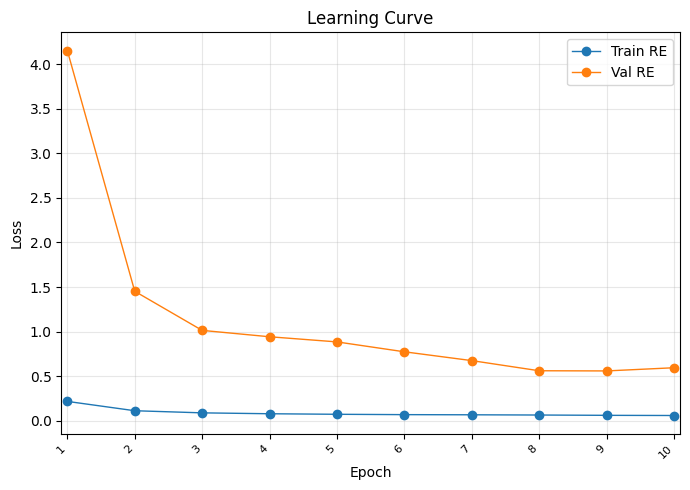

Epochs: 100%|██████████| 10/10 [02:16<00:00, 13.65s/ep, best=→ 0.4933, lr=1.00e-03, train=↓ 0.0619, val=↓ 0.4933]


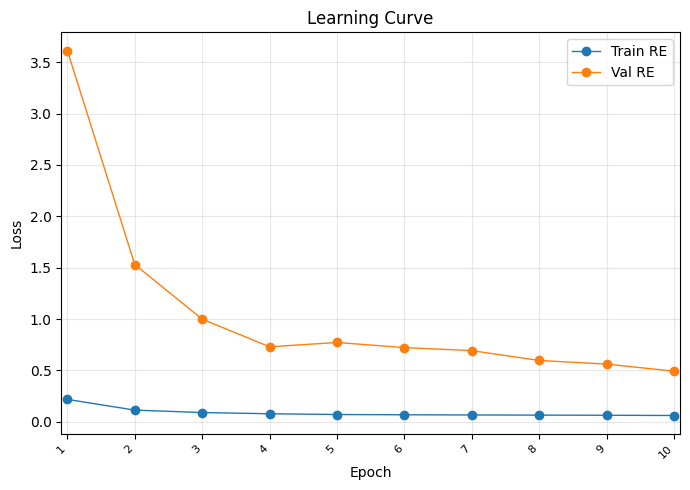

name:pre_model_run0.pth
 best val error:0.49331036584833404
 best train error:0.06191028282046318
 model params:2186



[(Autoencoder(
    (encoder): Sequential(
      (0): Sequential(
        (0): Linear(in_features=38, out_features=19, bias=True)
        (1): BatchNorm1d(19, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (1): Sequential(
        (0): Linear(in_features=19, out_features=9, bias=True)
        (1): BatchNorm1d(9, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (2): Sequential(
        (0): Linear(in_features=9, out_features=4, bias=True)
        (1): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (3): Sequential(
        (0): Linear(in_features=4, out_features=2, bias=True)
        (1): BatchNorm1d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
    )
    (decoder): Sequential(
      (0): Sequential(
        (0): Linear(in_features=2, out_features=4, bias=True)
        (1): Bat

In [11]:

for _ in range(2):
    
    n_restarts = cfg.n_restarts
    base_seed = cfg.seed

    best_val = np.inf
    best_run = None
    best_history = None
    run_histories = []
    filename_prefix = "pre_model_run"
    for i in range(0, n_restarts):
        
        cfg.set_seed(cfg.seed_list[i])
        
        model = tl.Autoencoder(cfg=cfg).to(cfg.device)

        optimizer = optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
        es = tl.EarlyStopping(min_delta=cfg.min_delta, patience=cfg.patience)
        
        fn_pre = f"{filename_prefix}{i}"

        history_info, _ = tl.train_with_early_stopping(
            model= model,
            train_loader=train_loader,
            val_loader = val_loader,
            optimizer = optimizer,
            config=cfg,
            es=es,
            loss_fn=nn.MSELoss(reduction="none"),
            scaler=None,
            filename_prefix=fn_pre,
        )

        run_histories.append(history_info["history"])
        curr_best = float(history_info["best_val"])
        
        if curr_best < best_val:
            best_val = curr_best
            best_run = i
            #best_history = history_info
    
        train_loader = hfn.rebuild_grouped_loader(train_loader,
                                                seed=cfg.seed, 
                                                shuffle=True, 
                                                batch_size=cfg.batch_size)
        # val_loader = hfn.rebuild_grouped_loader(val_loader,
        #                                         seed=cfg.seed,
        #                                         shuffle=False,
        #                                         batch_size=cfg.batch_size)
    
    pp.print_learning_curve(run_histories[best_run])
tl.get_model_results(ic.PATH_TO_BEST_MODEL_DIR)

### free Memory

In [12]:

val_loader = None

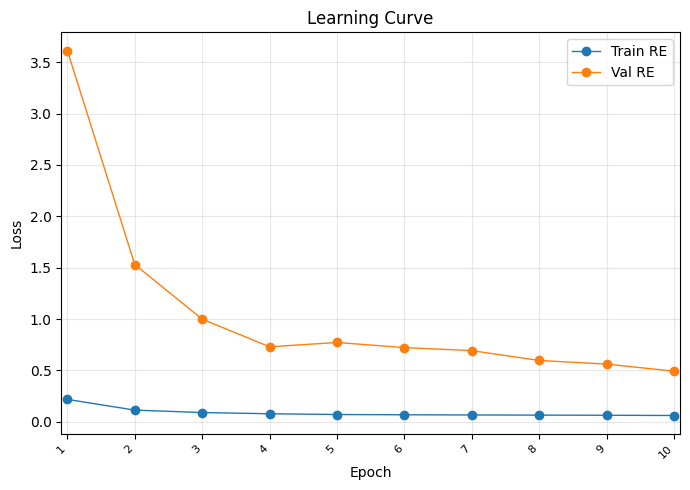

In [13]:
pp.print_learning_curve(run_histories[best_run])

#free memory
#run_histories = None

In [10]:
ae_list = tl.get_model_results(src=ic.PATH_TO_BEST_MODEL_DIR, best_n=1)
model, _ , ckpt, _, _ = ae_list[0]
model.eval()


name:activation__Seed_32_uid_8c8d353bea.pth
 best val error:0.17704901592204464
 best train error:0.009280807258664099
 model params:5425



Autoencoder(
  (encoder): Sequential(
    (0): Sequential(
      (0): Linear(in_features=38, out_features=28, bias=True)
      (1): BatchNorm1d(28, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.05)
    )
    (1): Sequential(
      (0): Linear(in_features=28, out_features=21, bias=True)
      (1): BatchNorm1d(21, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.05)
    )
    (2): Sequential(
      (0): Linear(in_features=21, out_features=16, bias=True)
      (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.05)
    )
    (3): Sequential(
      (0): Linear(in_features=16, out_features=12, bias=True)
      (1): BatchNorm1d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.05)
    )
    (4): Sequential(
      (0): Linear(in_features=12, out_features=9, bia

### Evaluation

In [11]:
# mean, elem_losses, uid_batches = tl.validate_epoch(
#     model=model,
#     loader=test_loader,
#     device=cfg.device,
#     loss_fn=nn.MSELoss(reduction="none"),
#     return_uids=True
# )

# df_test_eval = tl.uids_to_wt_ts(
#     uid_batches=uid_batches,
#     elem_losses=elem_losses,
#     loader=test_loader)

# df_test_eval.head()

df_test_eval = tl.eval_model(model,
                             data_loader= test_loader,
                             device=cfg.device,
                             loss_fn=nn.MSELoss(reduction="none"),
                             )

df_test_eval.head(24)
#TODO
#save df_test_eval with config-name
# dir = Path(ckpt["dir_path"])
# dir.mkdir(parents=True, exist_ok=True)
# df_test_eval.to_csv((dir/ ic.EVAL_FILE_NAME))

,uid,Date and time,WT_ID,Mean Loss per Sample,RE_Ambient temperature (converter) (°C),RE_Drive train acceleration (mm/ss),RE_Gear oil inlet pressure (bar),RE_Gear oil pump pressure (bar),RE_Gearbox speed (RPM),RE_Generator bearing front temperature (°C),...,RE_Blade angle (pitch position) C (°),RE_Front bearing temperature (°C),RE_Gear oil inlet temperature (°C),RE_Gear oil temperature (°C),RE_Rear bearing temperature (°C),RE_Tower Acceleration X (mm/ss),RE_Tower Acceleration Y (mm/ss),RE_Transformer cell temperature (°C),RE_Transformer temperature (°C),RE_Yaw bearing angle (°)
842250,1588306200000000001,2020-05-01 04:10:00,1,0.021798,0.008148,9.448658e-02,0.020666,0.021166,0.002876,0.011175,...,0.002781,0.001968,0.000169,0.004524,4.390480e-05,0.000239,0.012340,0.000073,0.000367,0.236192
982625,1588306200000000002,2020-05-01 04:10:00,2,0.026611,0.005555,1.478810e-01,0.003152,0.005707,0.000037,0.000812,...,0.000992,0.014479,0.004077,0.037727,1.431968e-02,0.001727,0.014470,0.003942,0.013449,0.237053
1123000,1588306200000000004,2020-05-01 04:10:00,4,0.002452,0.000042,7.215204e-06,0.002139,0.001538,0.000092,0.000897,...,0.000284,0.000529,0.000318,0.003309,7.200769e-05,0.000651,0.005969,0.000130,0.000011,0.000130
1263375,1588306200000000005,2020-05-01 04:10:00,5,0.013120,0.005832,3.509925e-02,0.013446,0.022986,0.000044,0.008692,...,0.000418,0.002332,0.004244,0.015442,1.185353e-03,0.018634,0.051762,0.007190,0.001146,0.000083
1403750,1588306200000000006,2020-05-01 04:10:00,6,0.013144,0.000221,4.348456e-02,0.000567,0.001858,0.005117,0.000530,...,0.000232,0.000188,0.000374,0.001174,1.620567e-03,0.000152,0.001344,0.002955,0.003236,0.000237
1544125,1588306200000000007,2020-05-01 04:10:00,7,0.005935,0.000269,8.422837e-03,0.006917,0.013925,0.000871,0.013131,...,0.000509,0.000957,0.000005,0.000761,5.085258e-07,0.003082,0.024493,0.000310,0.000195,0.000038
1684500,1588306200000000008,2020-05-01 04:10:00,8,0.008425,0.002394,3.277531e-02,0.001448,0.000824,0.000022,0.003916,...,0.008908,0.005120,0.000051,0.000887,6.060054e-05,0.001336,0.002472,0.003750,0.000680,0.000008
1824875,1588306200000000009,2020-05-01 04:10:00,9,0.022295,0.000887,4.638756e-03,0.107636,0.095875,0.000226,0.001229,...,0.000877,0.030392,0.000661,0.007371,1.056704e-02,0.033783,0.038221,0.013951,0.007267,0.000019
0,1588306200000000010,2020-05-01 04:10:00,10,0.009312,0.014664,3.662919e-06,0.142575,0.076996,0.000109,0.002917,...,0.000524,0.013081,0.002764,0.003681,5.958721e-03,0.007983,0.003652,0.010887,0.000836,0.000077
140375,1588306200000000011,2020-05-01 04:10:00,11,0.459558,0.026261,4.280357e-01,0.605449,0.523935,0.676062,0.484901,...,0.369295,0.364407,0.004656,0.414489,5.281938e-01,0.874749,0.731121,0.497776,0.609198,0.029049


### free memory

In [16]:
#test_loader = None

In [20]:
ae_list= tl.get_model_results(ic.PATH_TO_BEST_MODEL_DIR, best_n=1)
p = ae_list[0][2]['dir_path']

df_test_eval = pd.read_csv(os.path.join(p, ic.EVAL_FILE_NAME))

name:activation__Seed_32_uid_8c8d353bea.pth
 best val error:0.17704901592204464
 best train error:0.009280807258664099
 model params:5425



FileNotFoundError: [Errno 2] No such file or directory: 'F:\\Shin_Abschlussarbeit\\github\\BSc-Thesis-Multi-Wind-Turbine-AD\\src\\early_stopping\\activation__Seed_32_uid_8c8d353bea\\eval.csv'

In [6]:
df_test_eval.head()

NameError: name 'df_test_eval' is not defined

### Visualization of Test Set Evaluation

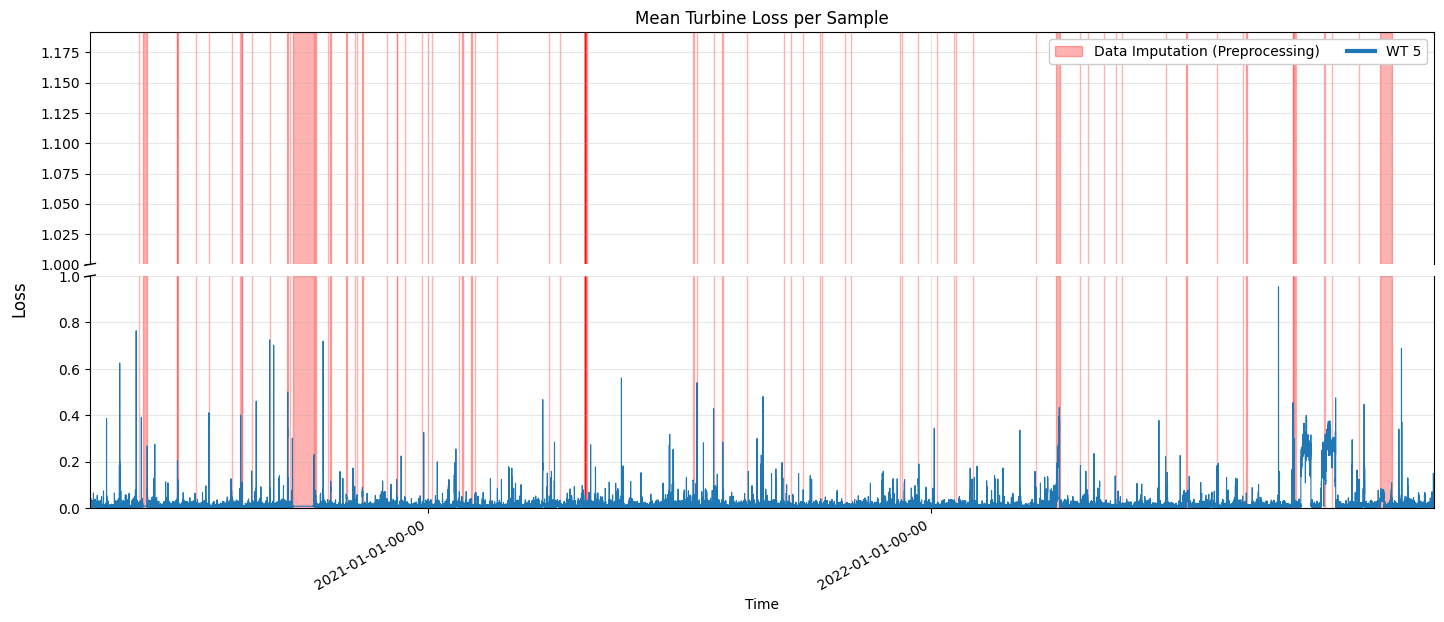

In [27]:
pp.print_loss(
            df_test_eval, 
            dpi=300,
            wt_id=[5],
            y_limits=((0,1),(1,35)), 
            )

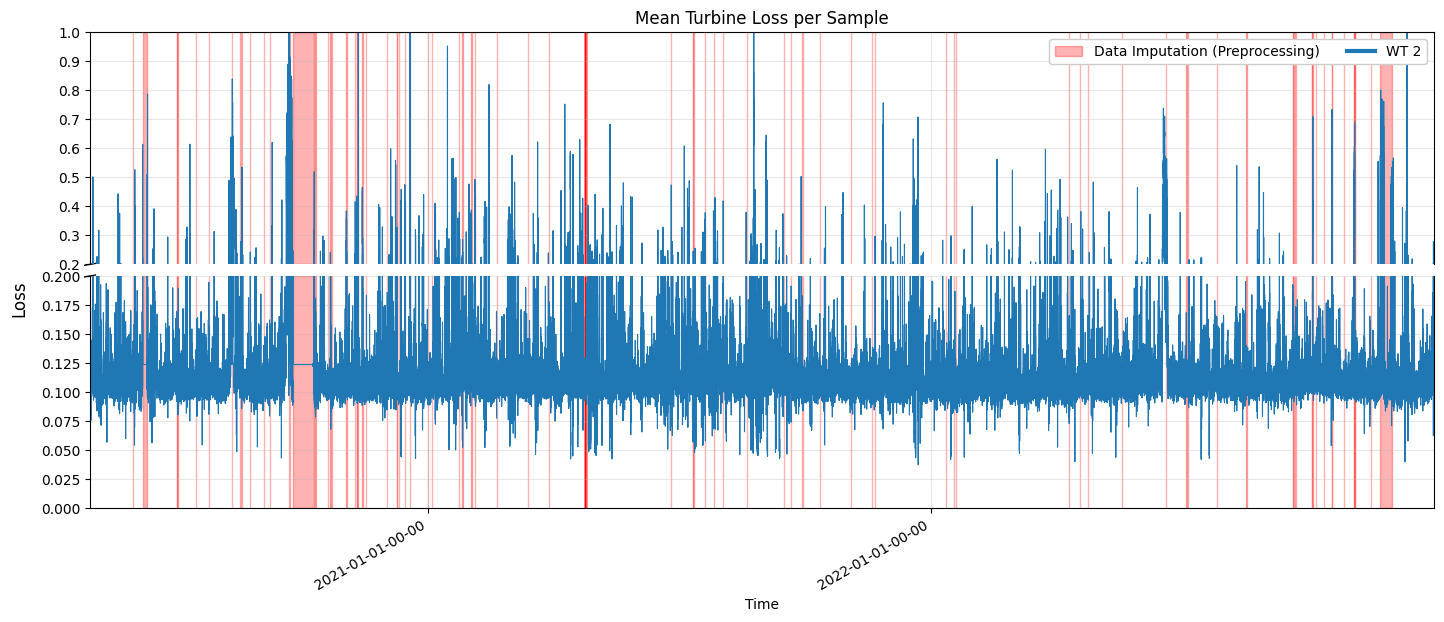

In [20]:
pp.print_loss(
            df_test_eval, 
            dpi=300, 
            y_limits=((0,0.2),(0.2,1)), 
            wt_id=[2]
            )

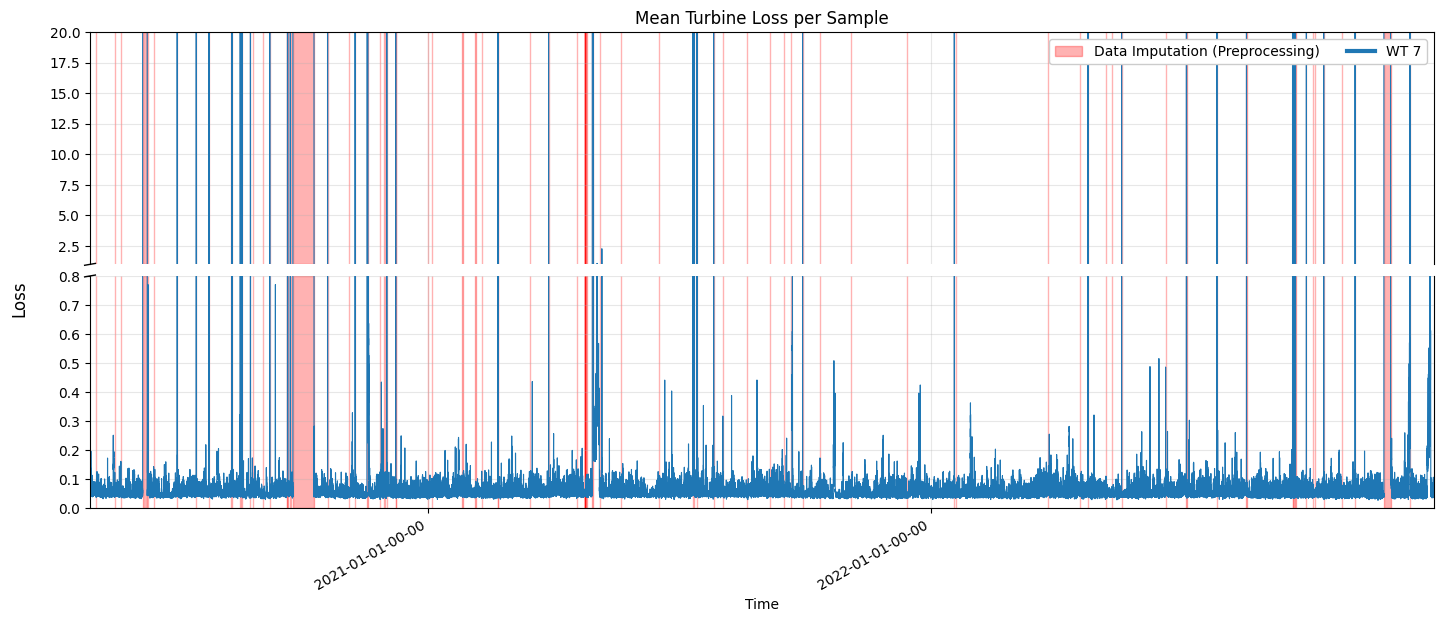

In [21]:
pp.print_loss(
            df_test_eval, 
            dpi=300, 
            y_limits=((0,0.8),(1,20)), 
            wt_id=[7]
            )

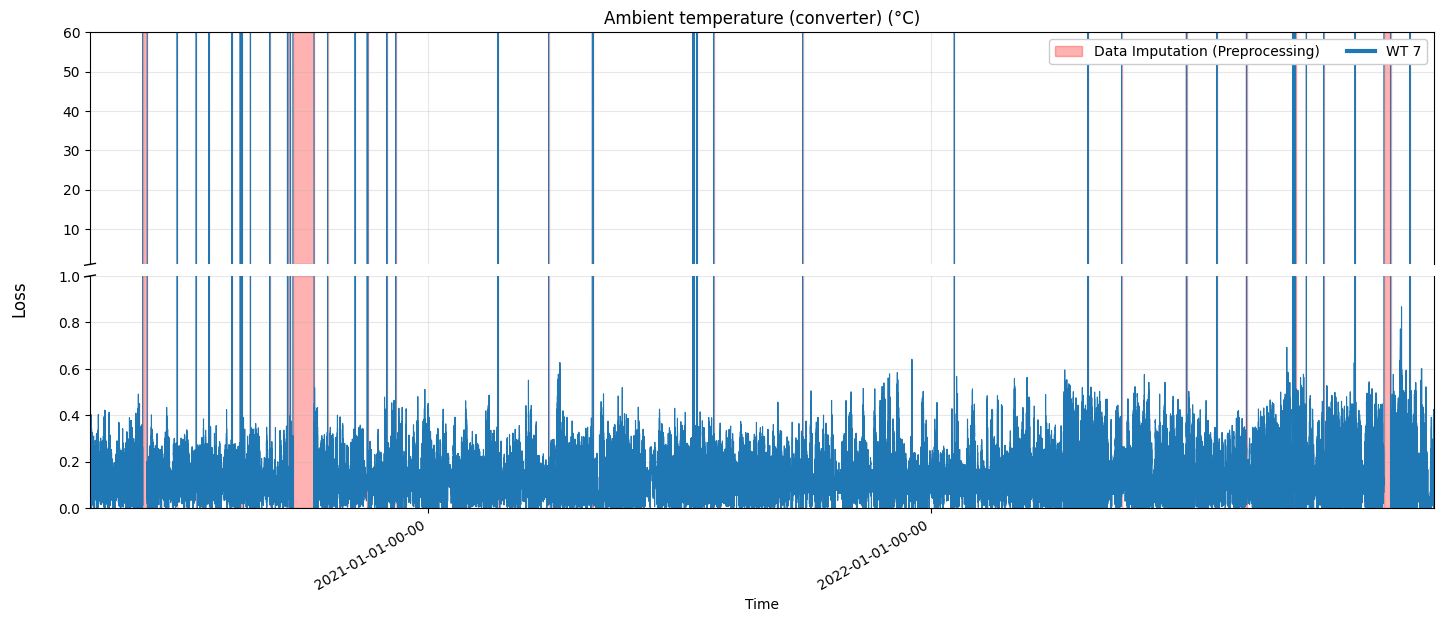

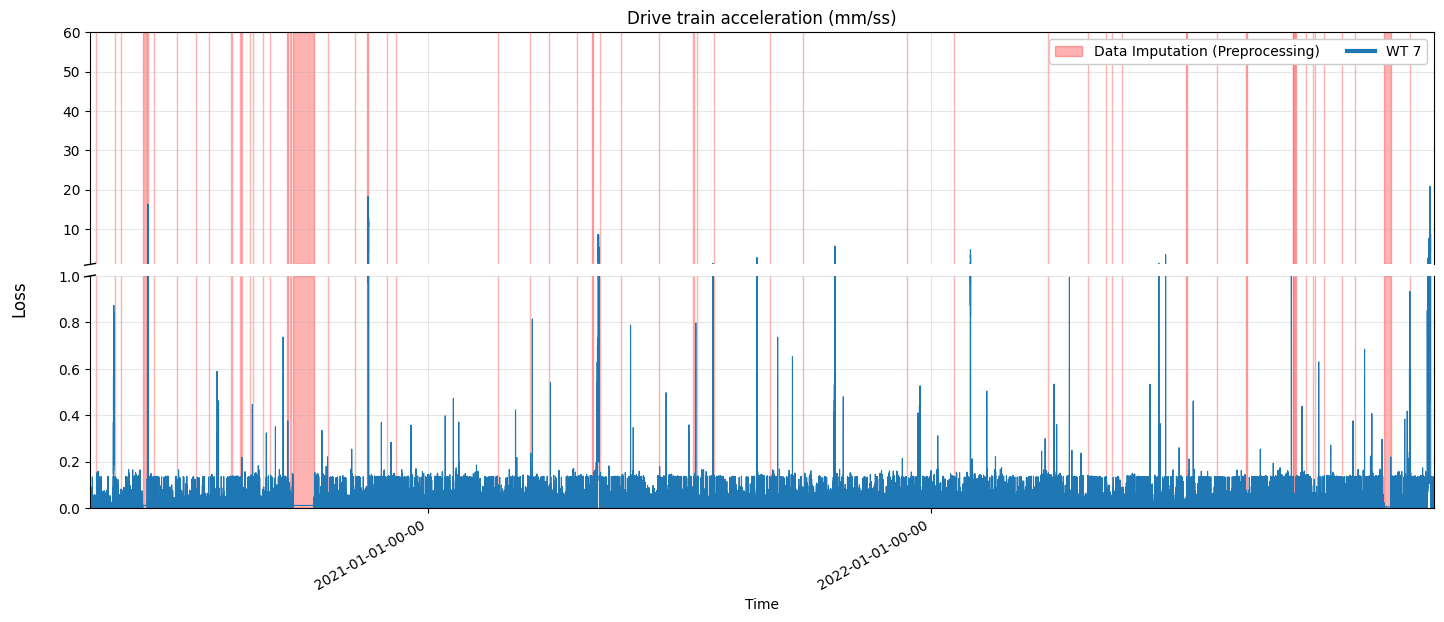

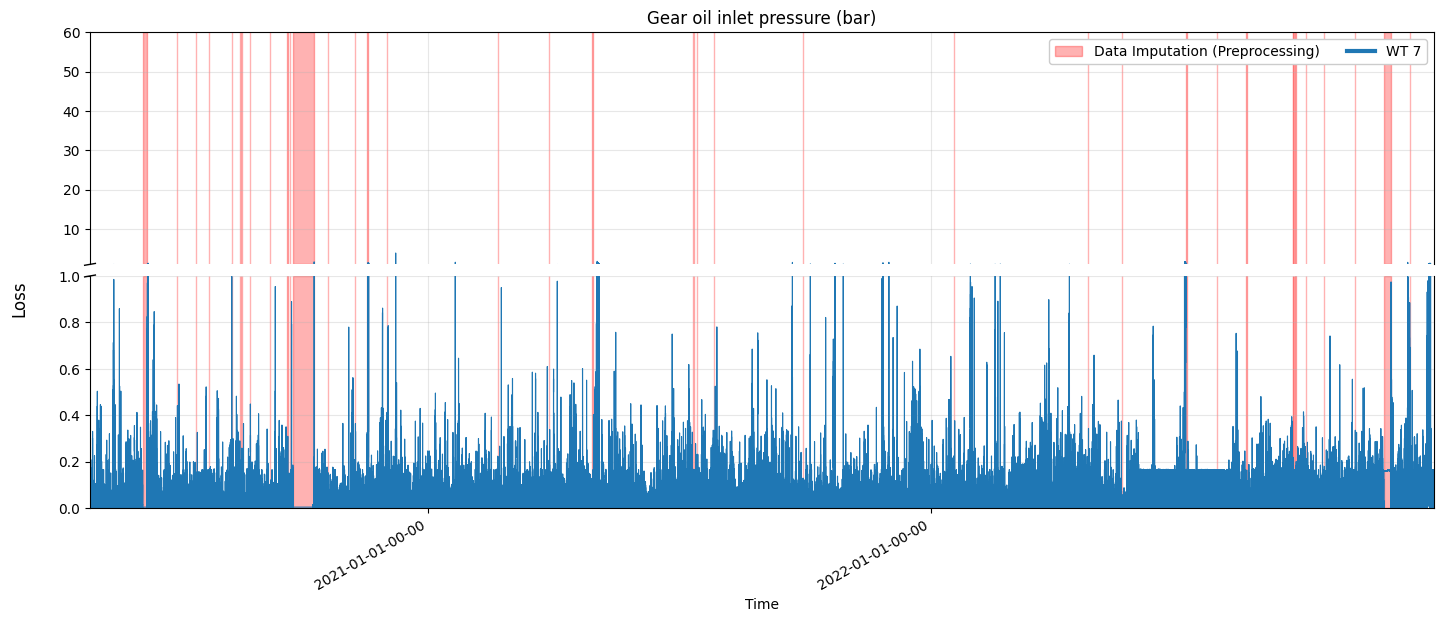

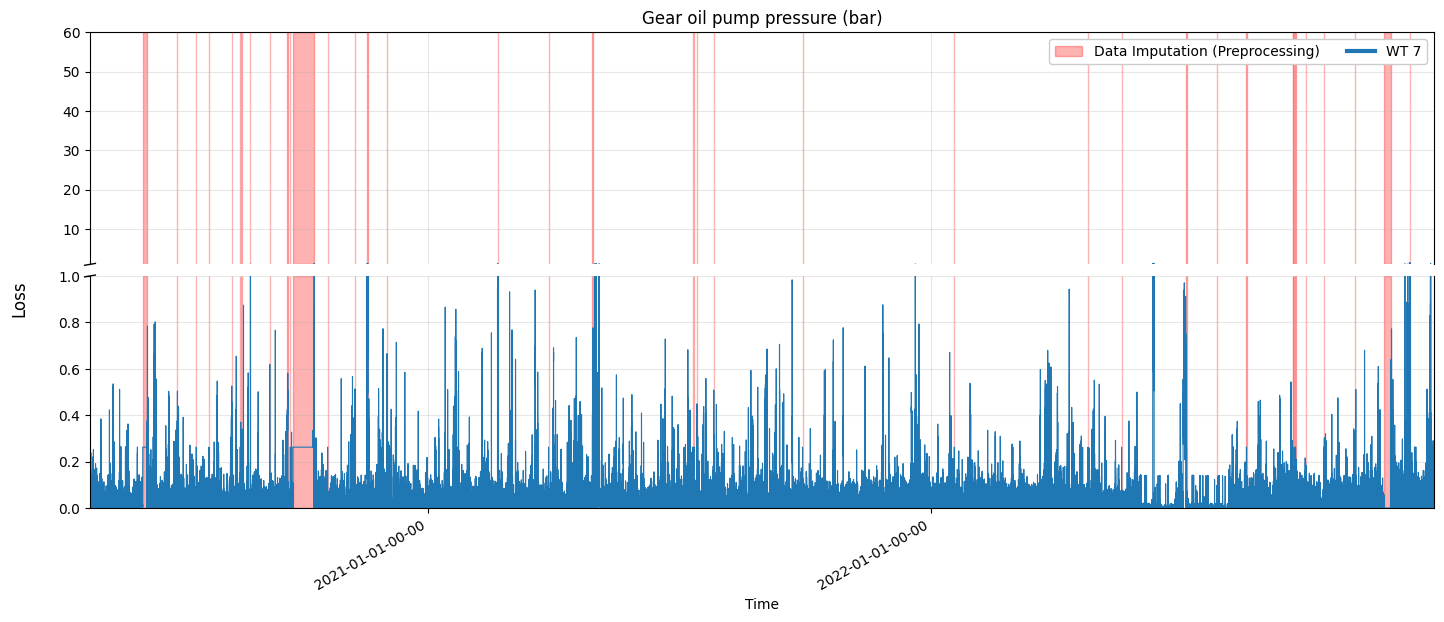

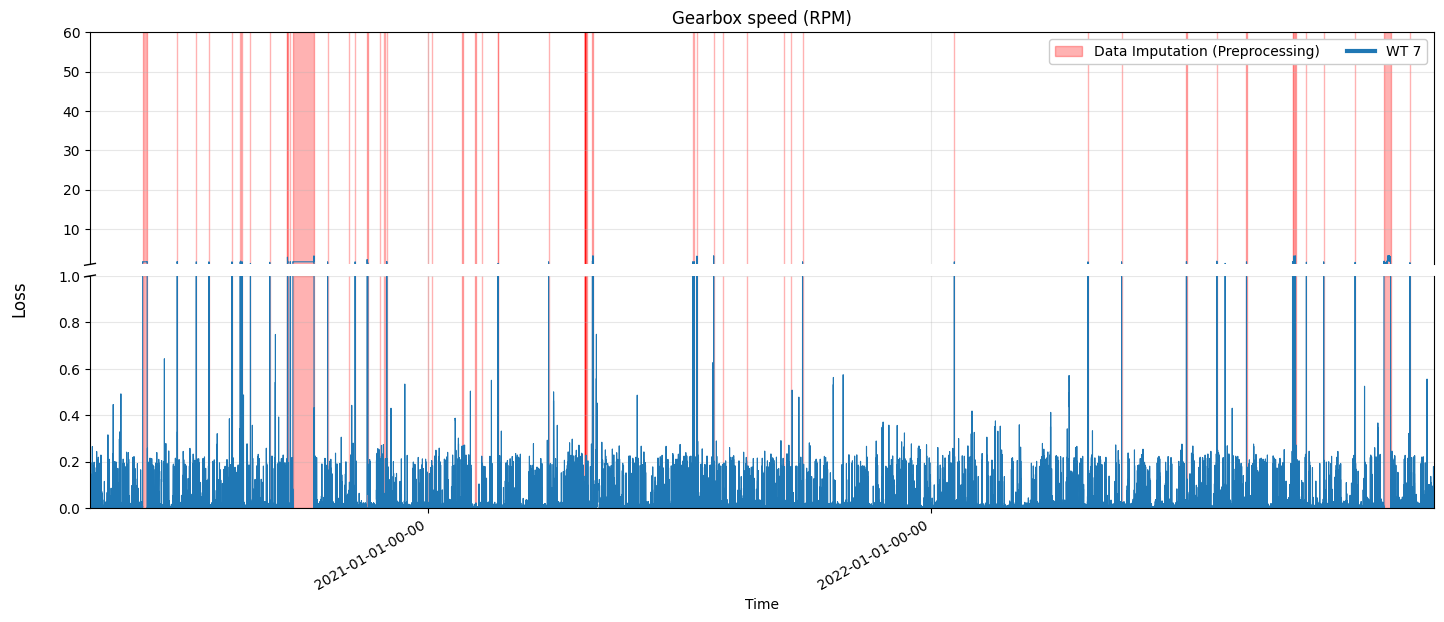

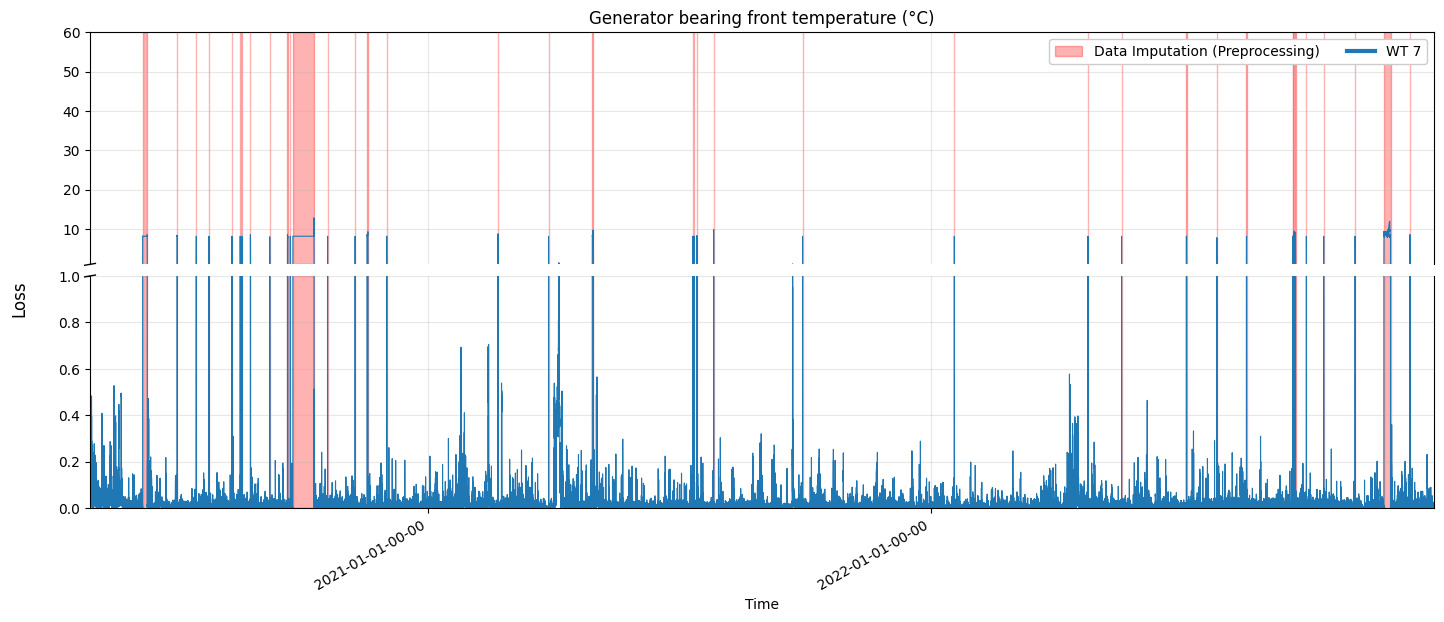

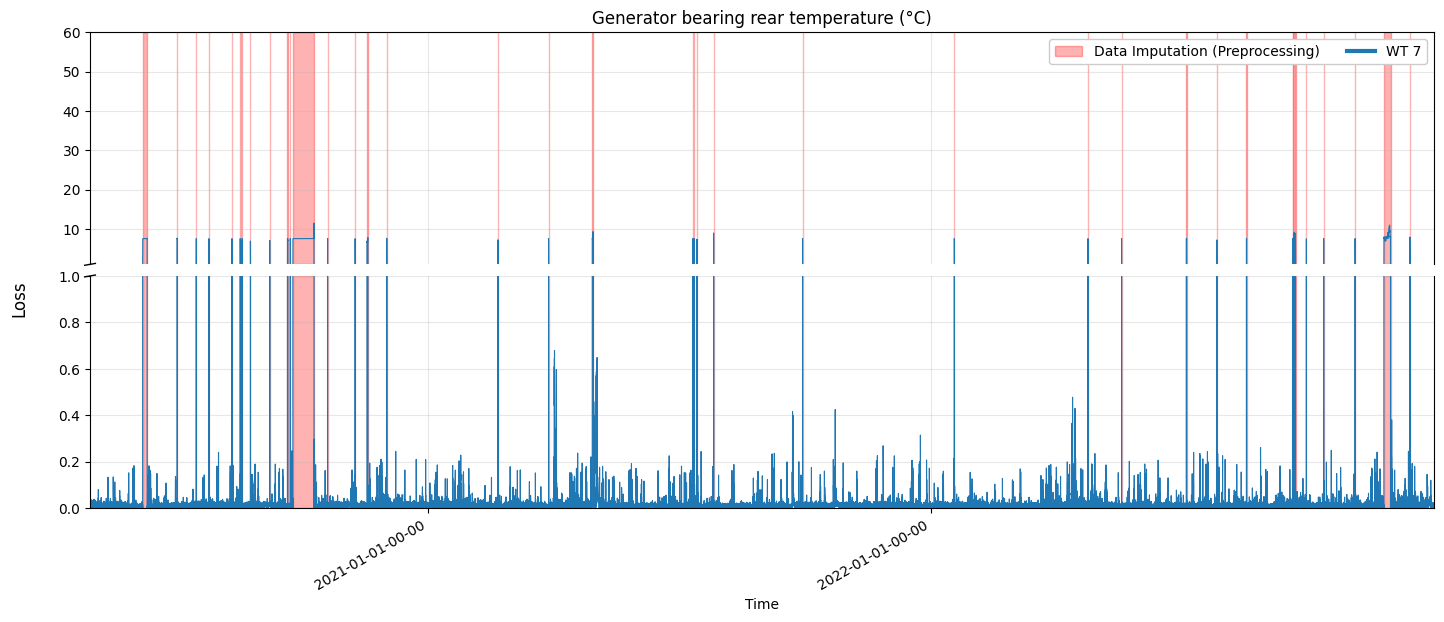

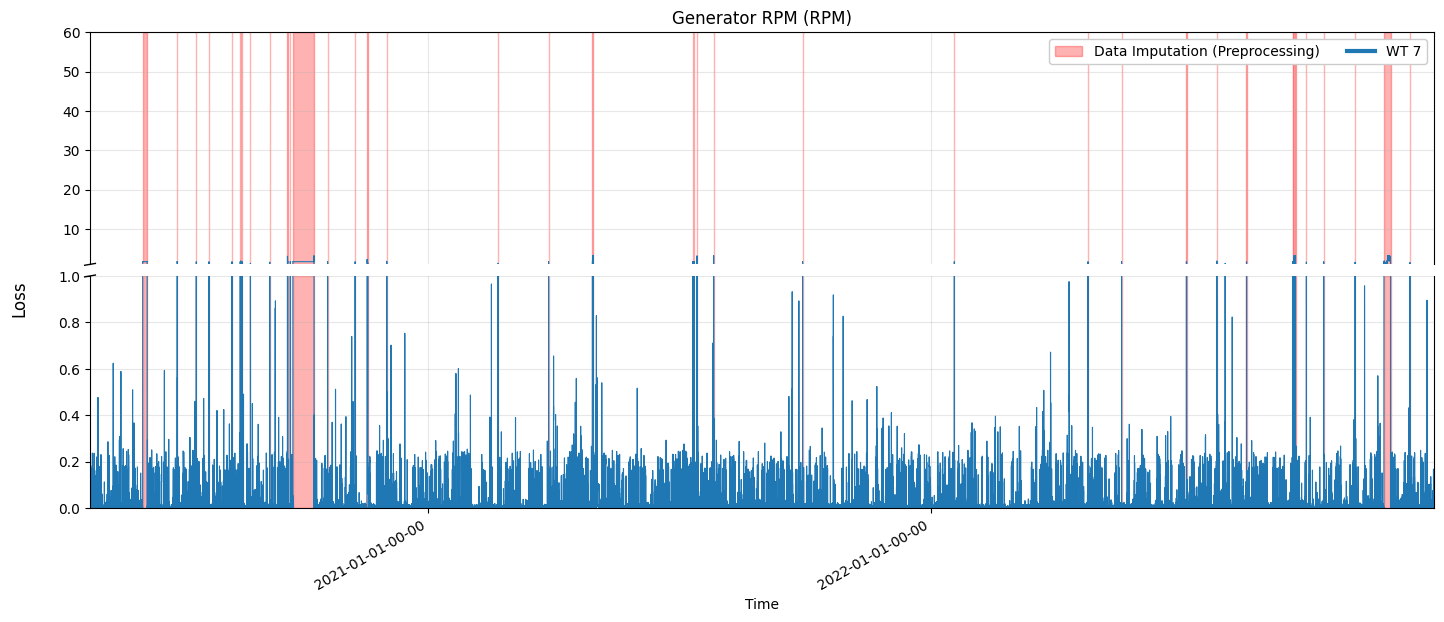

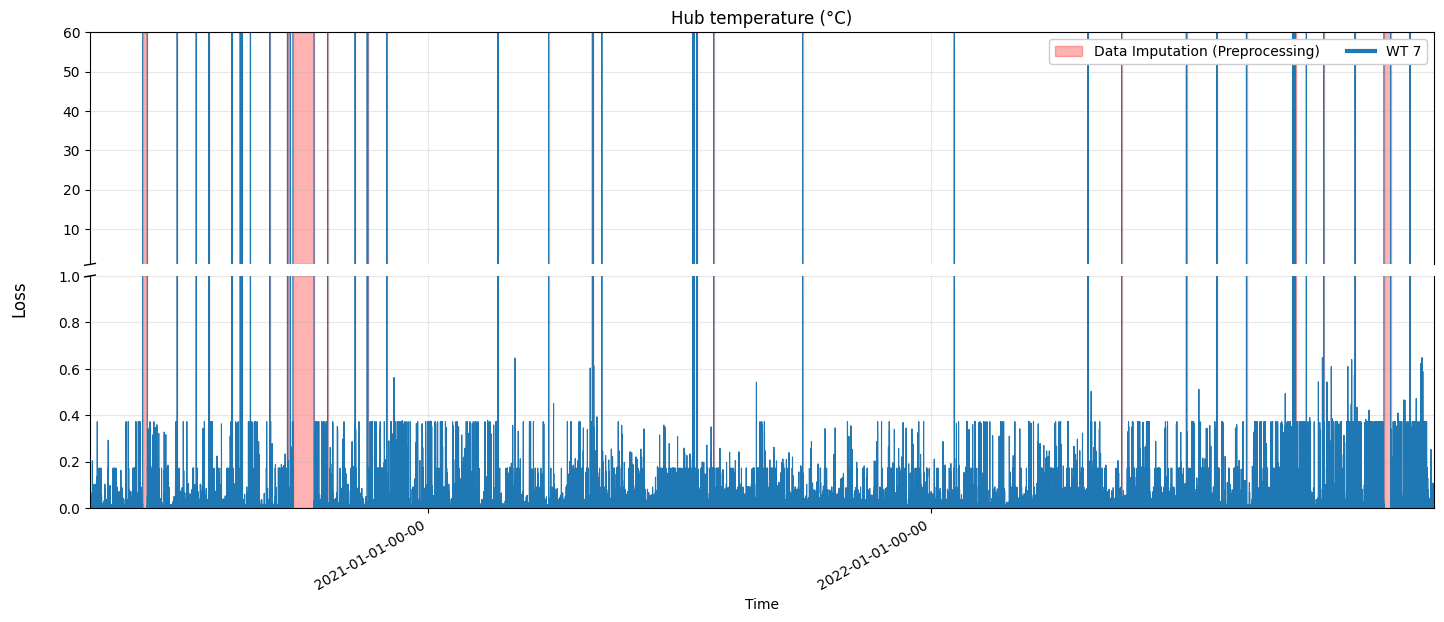

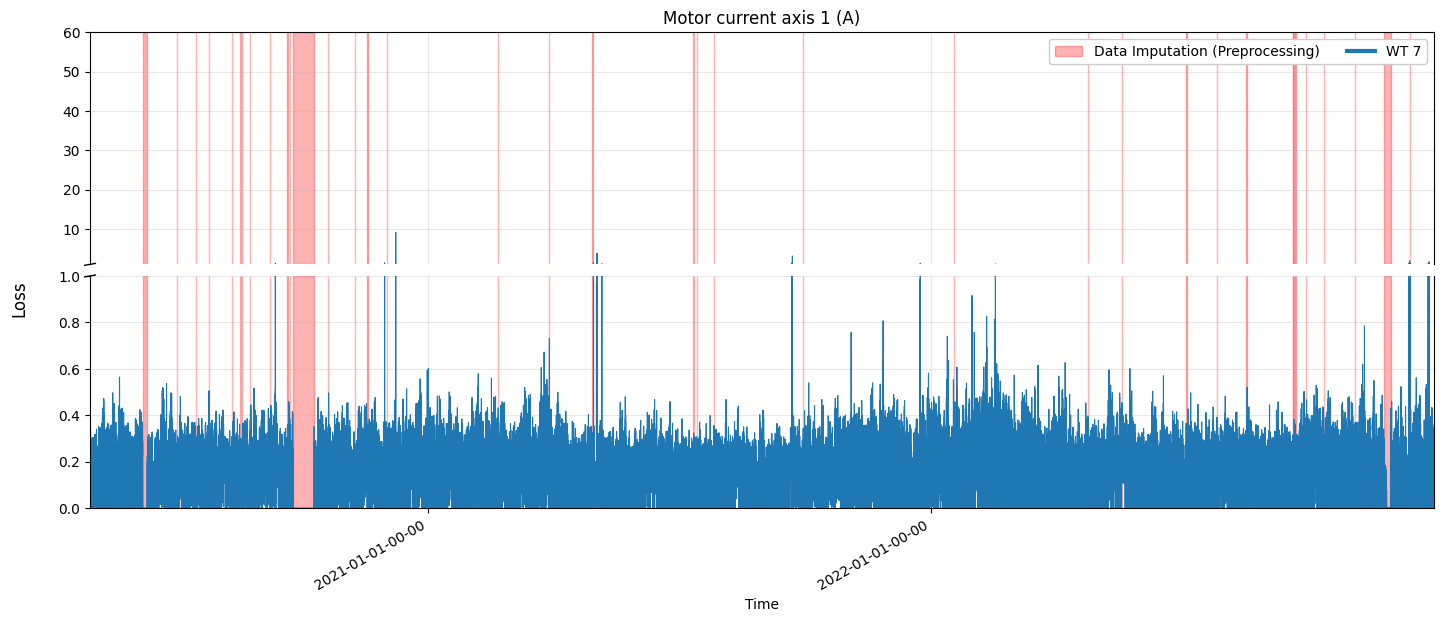

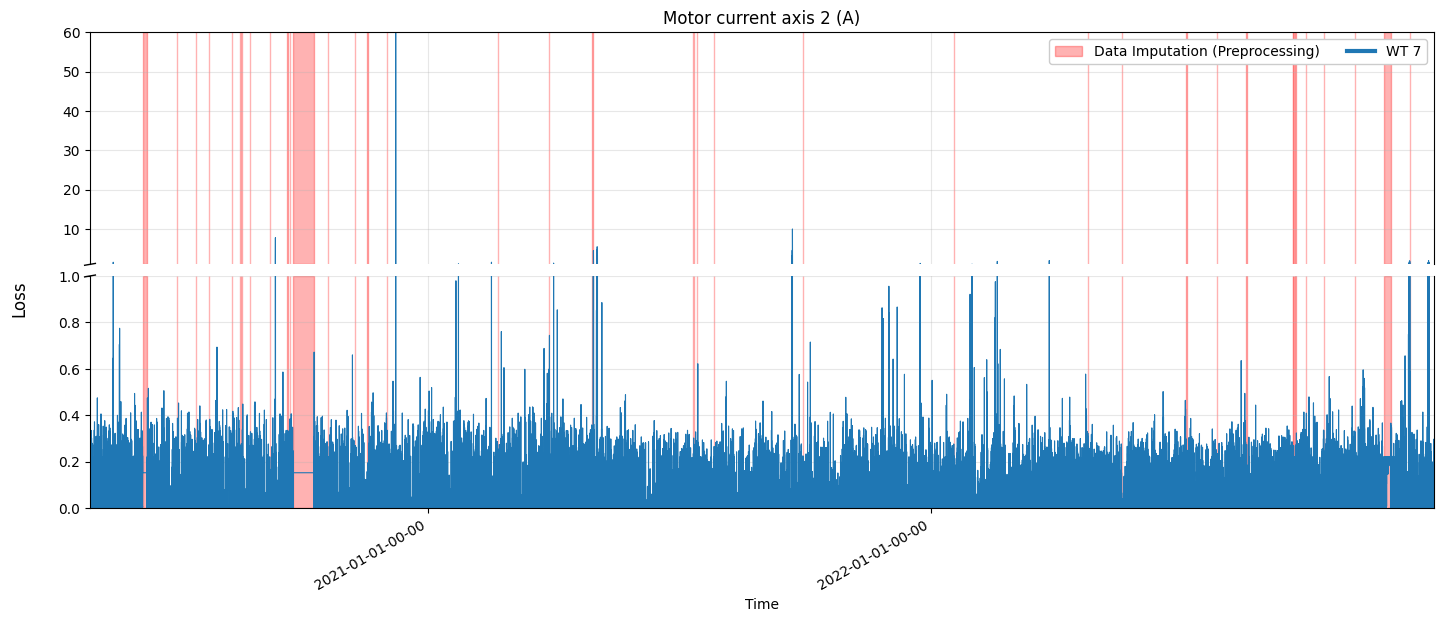

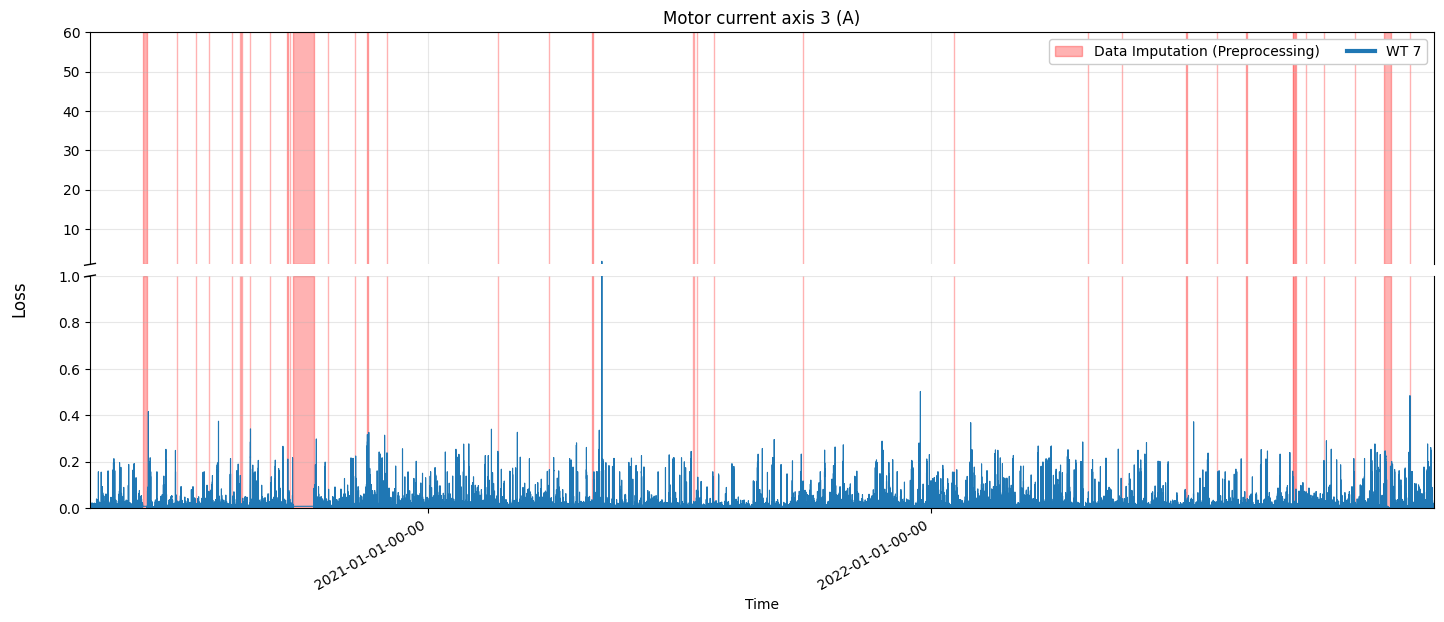

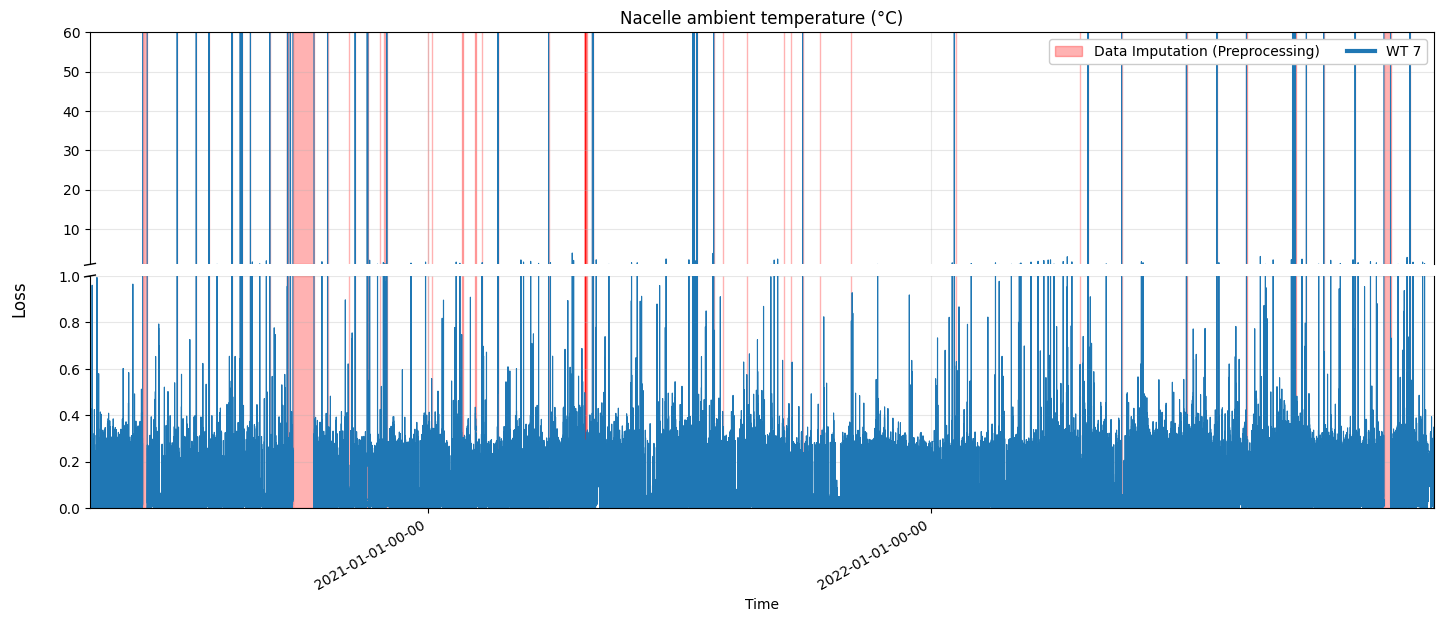

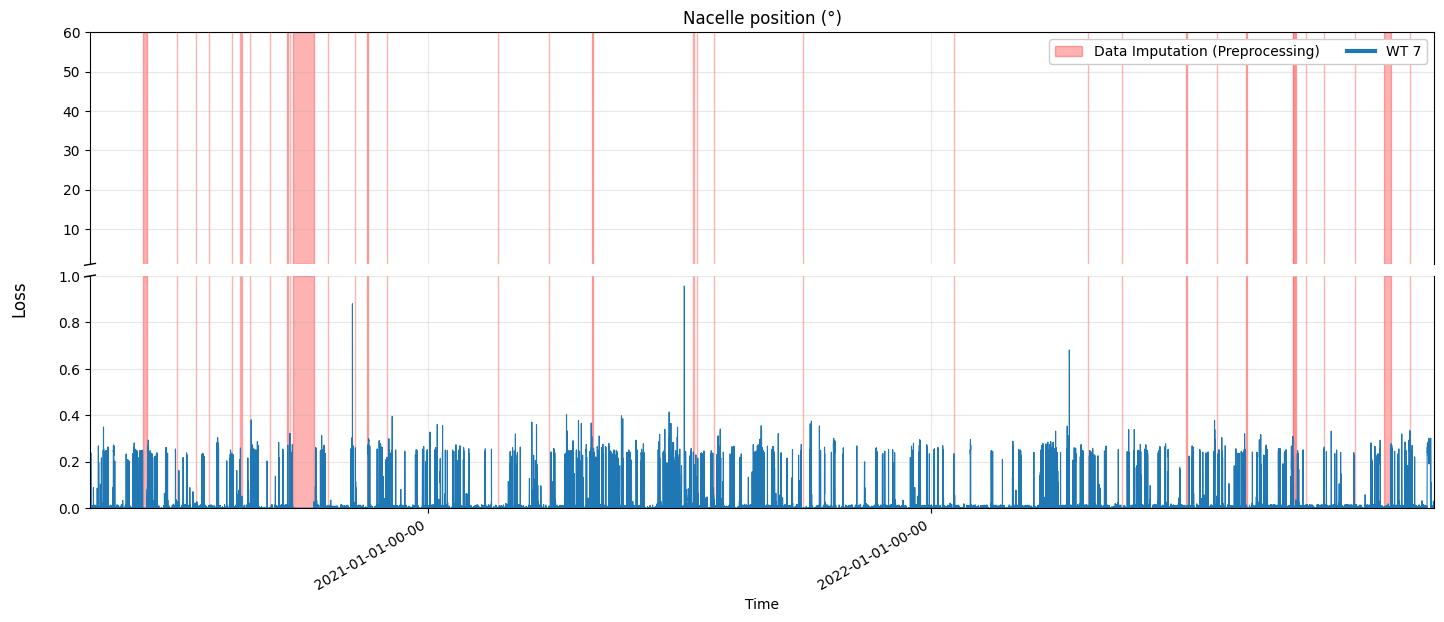

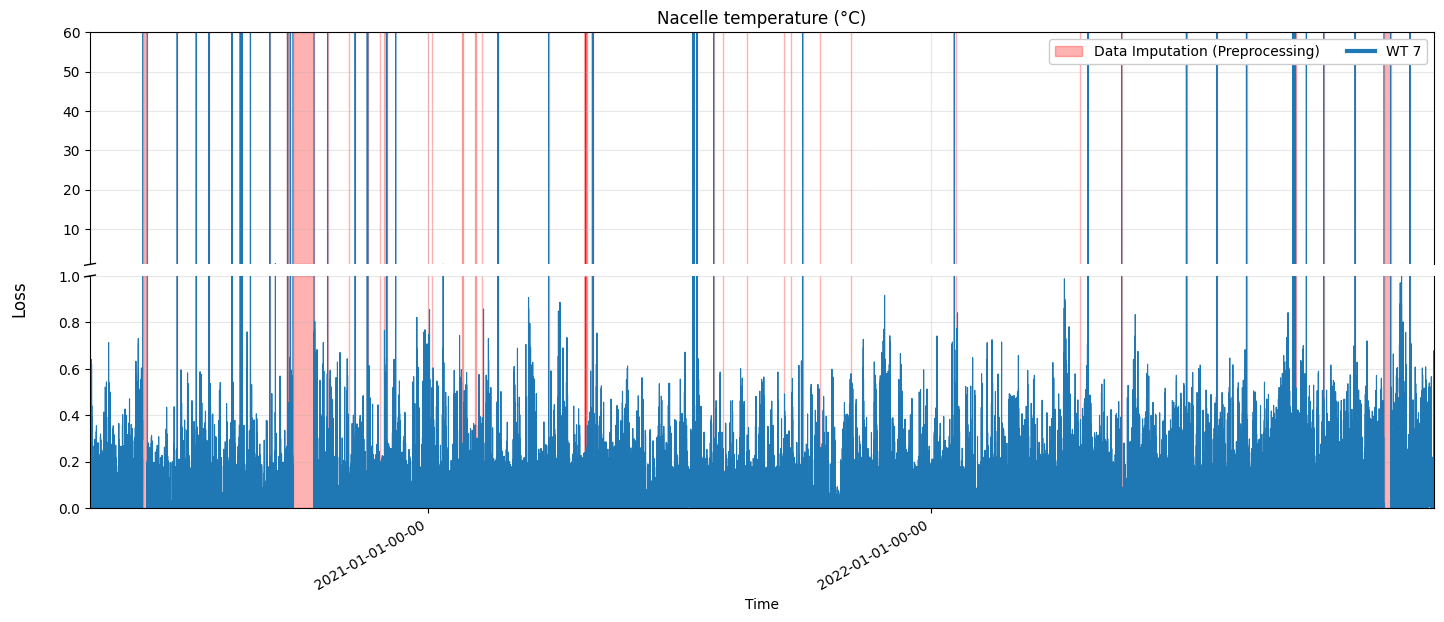

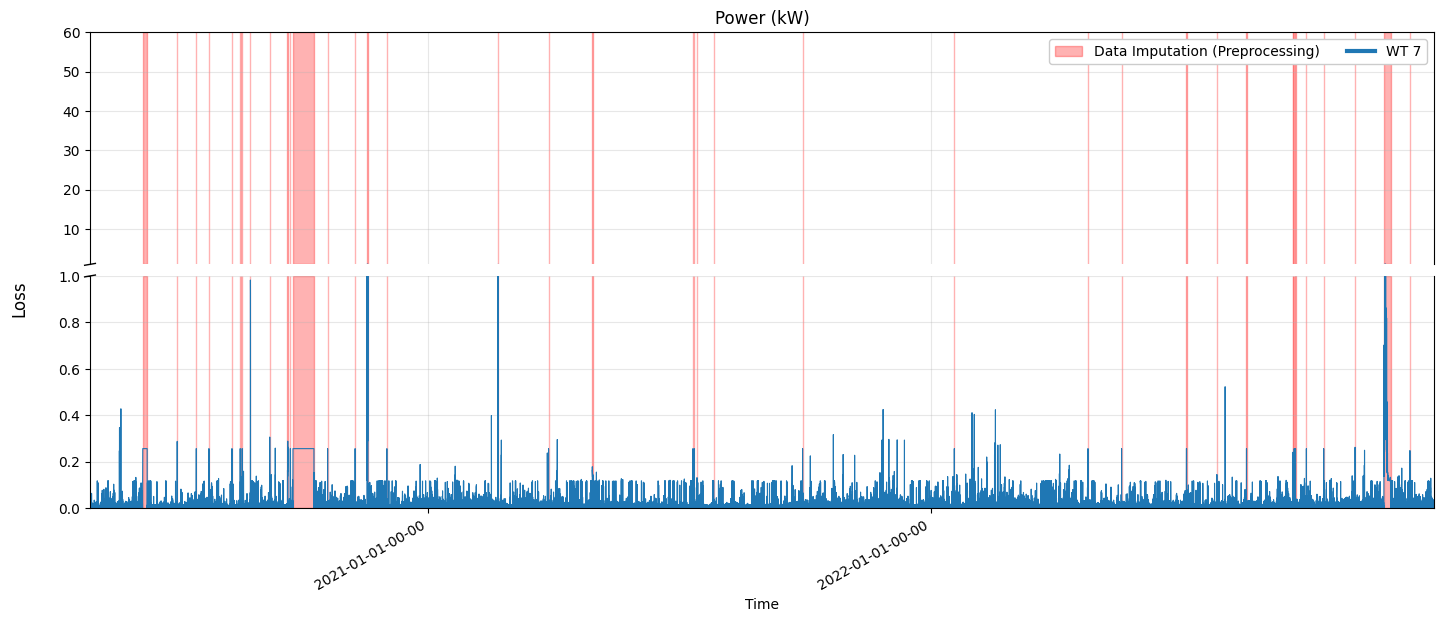

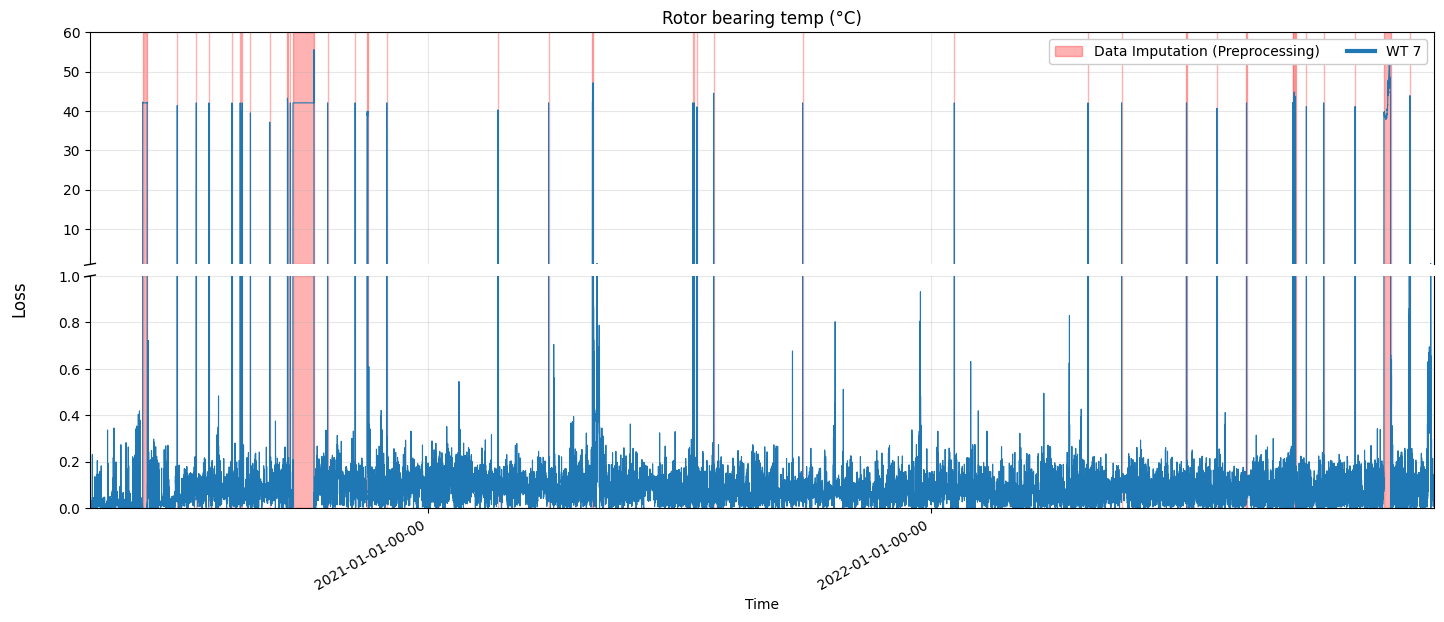

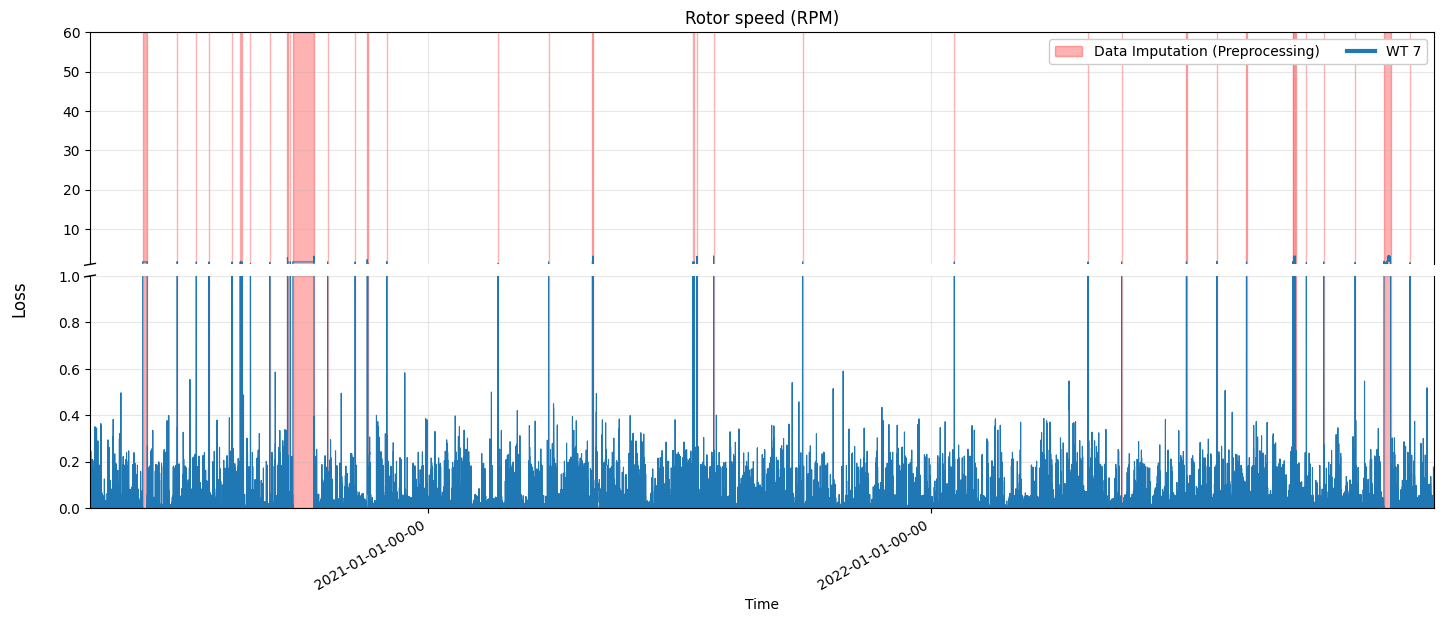

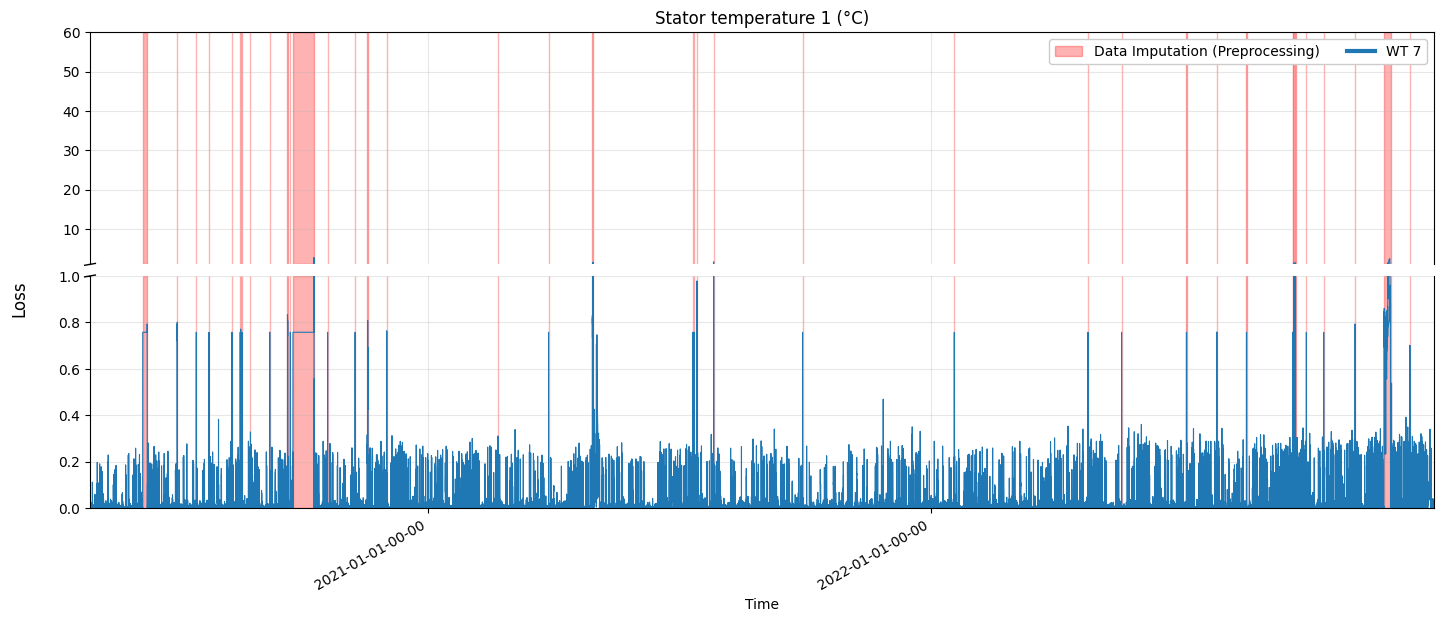

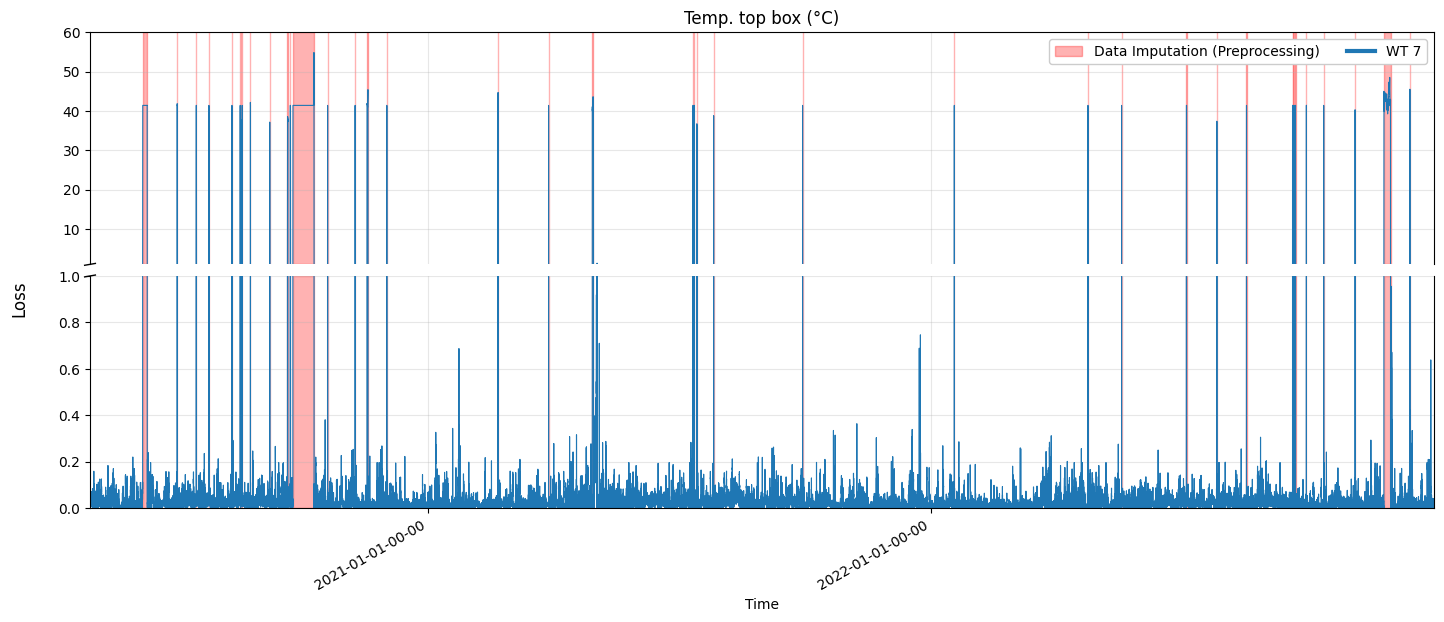

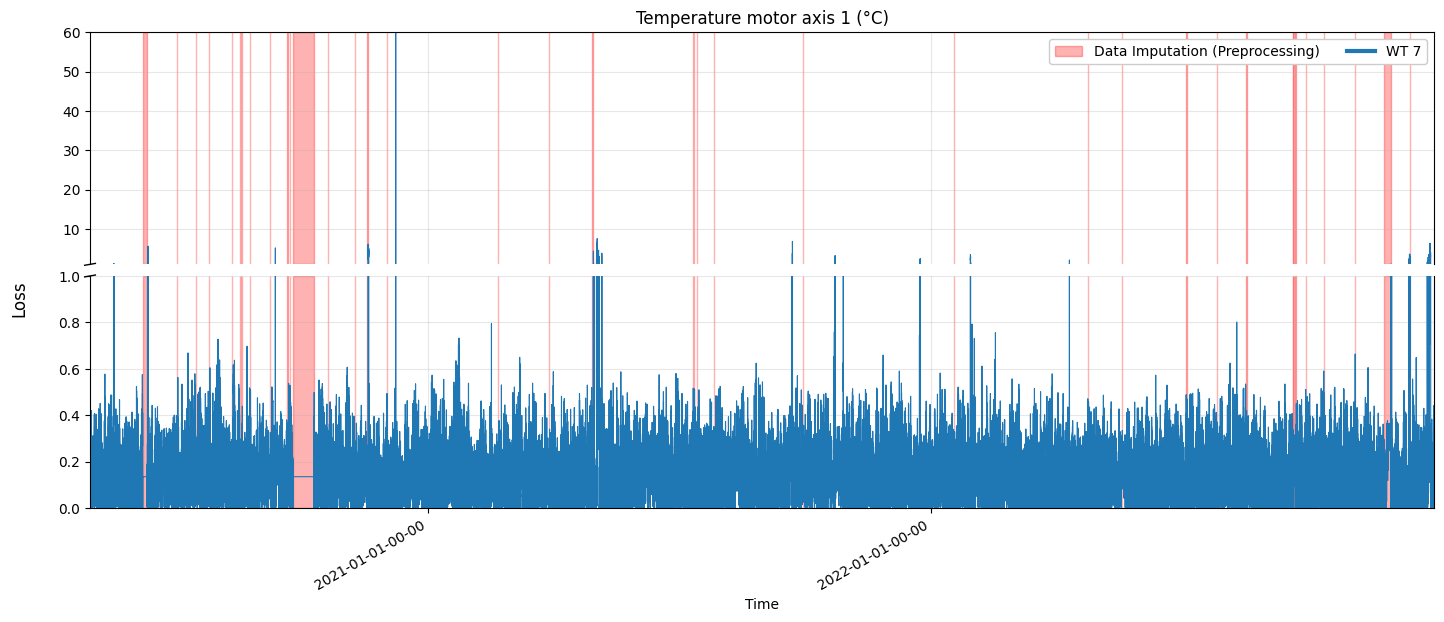

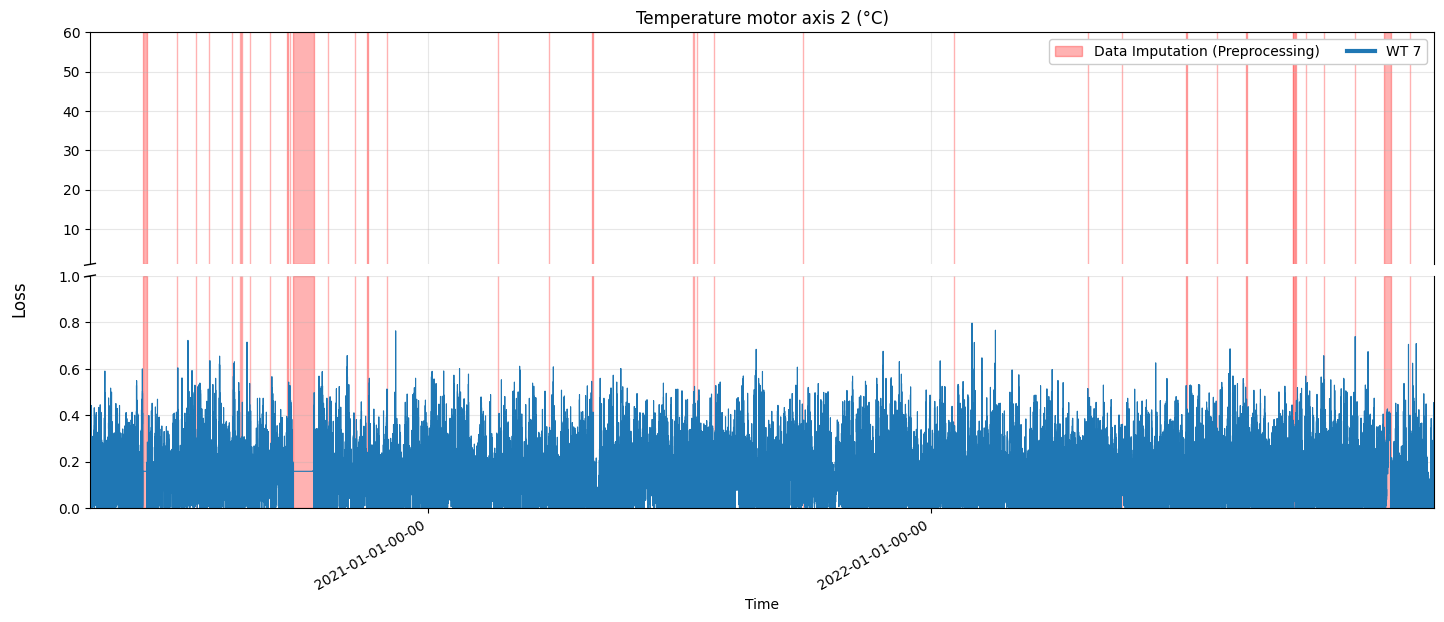

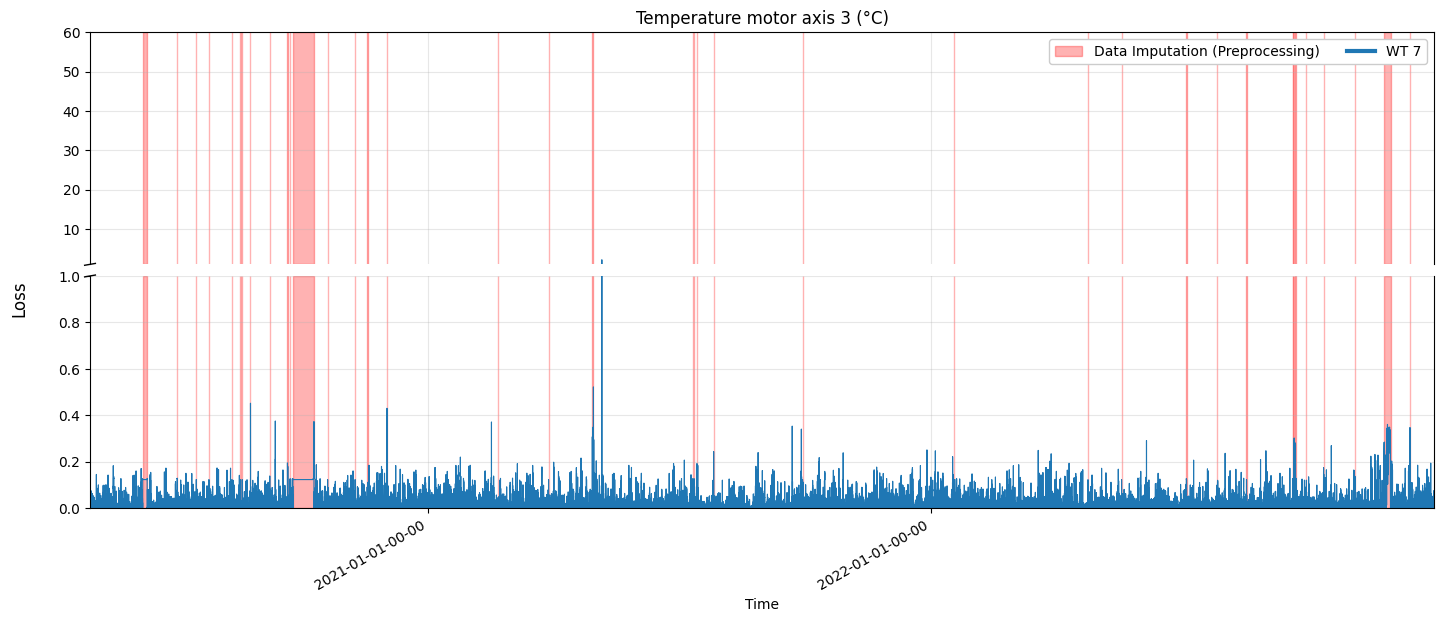

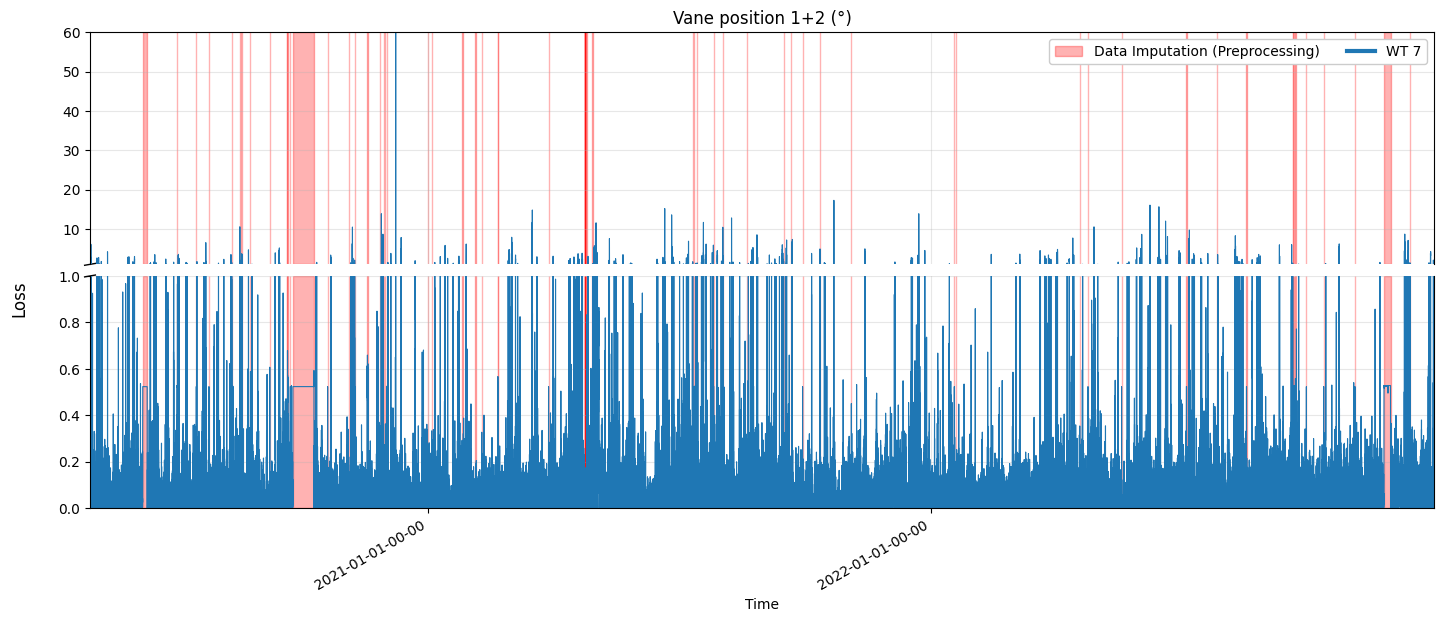

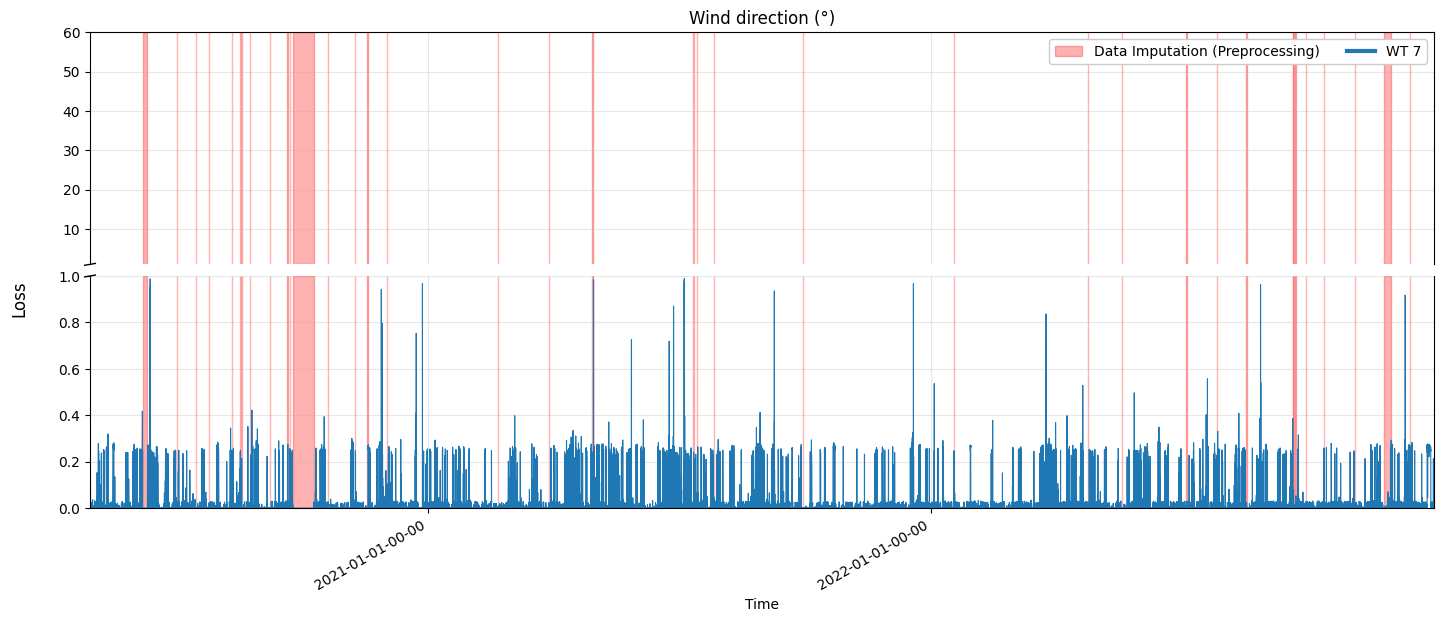

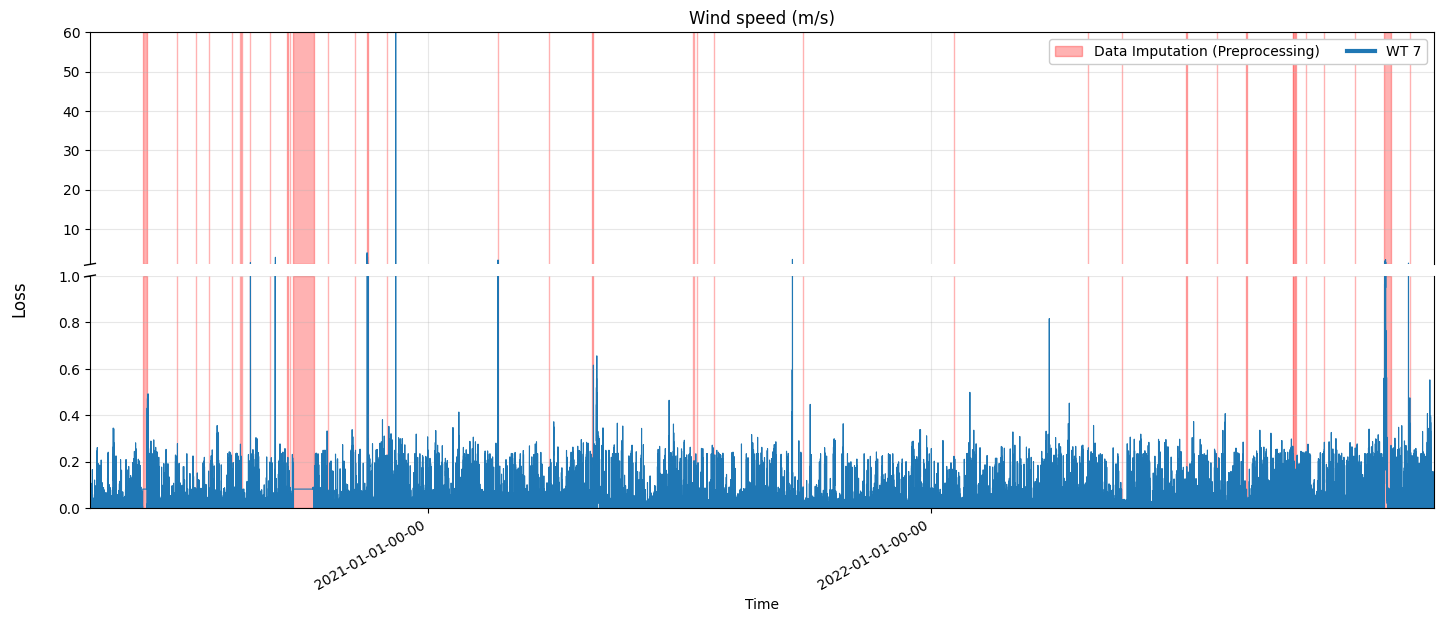

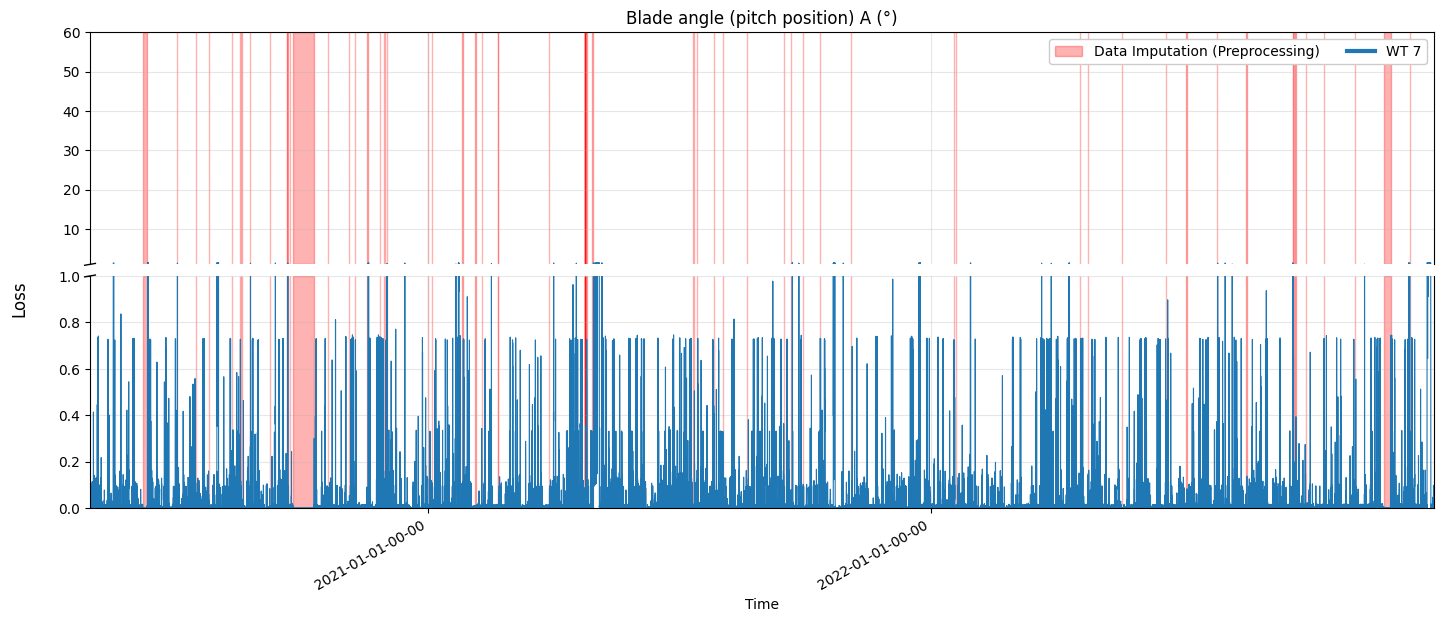

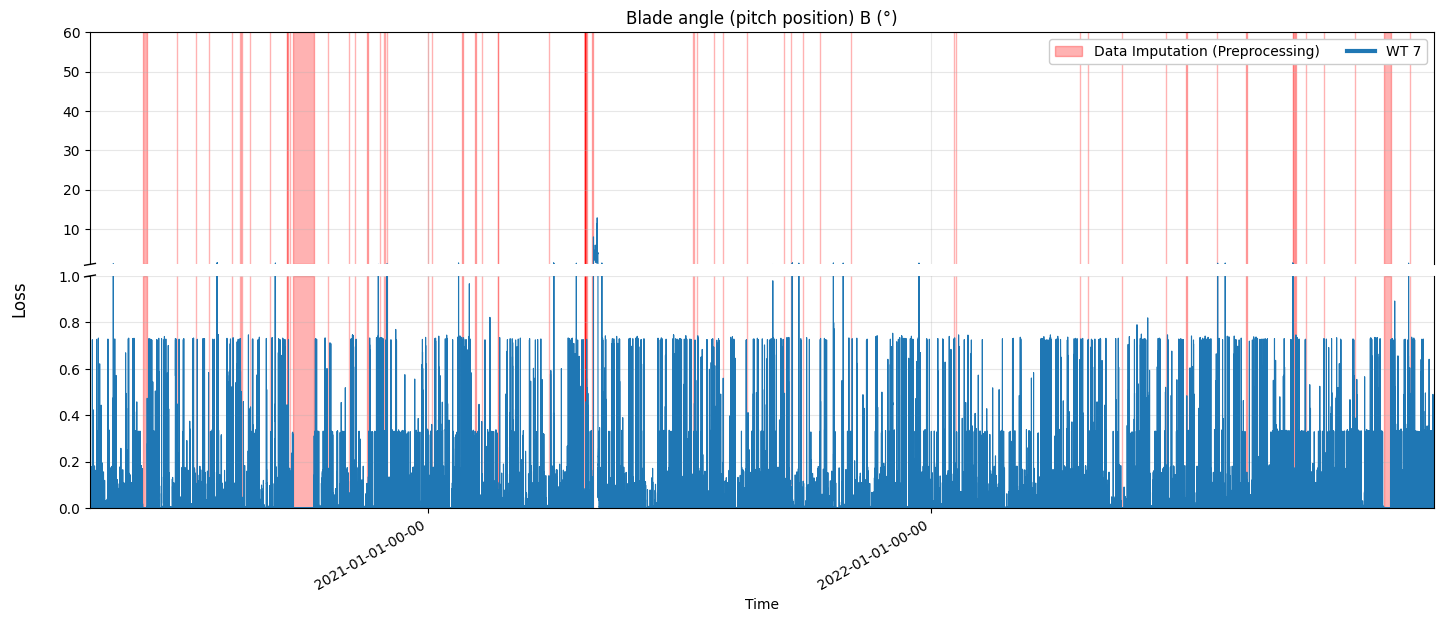

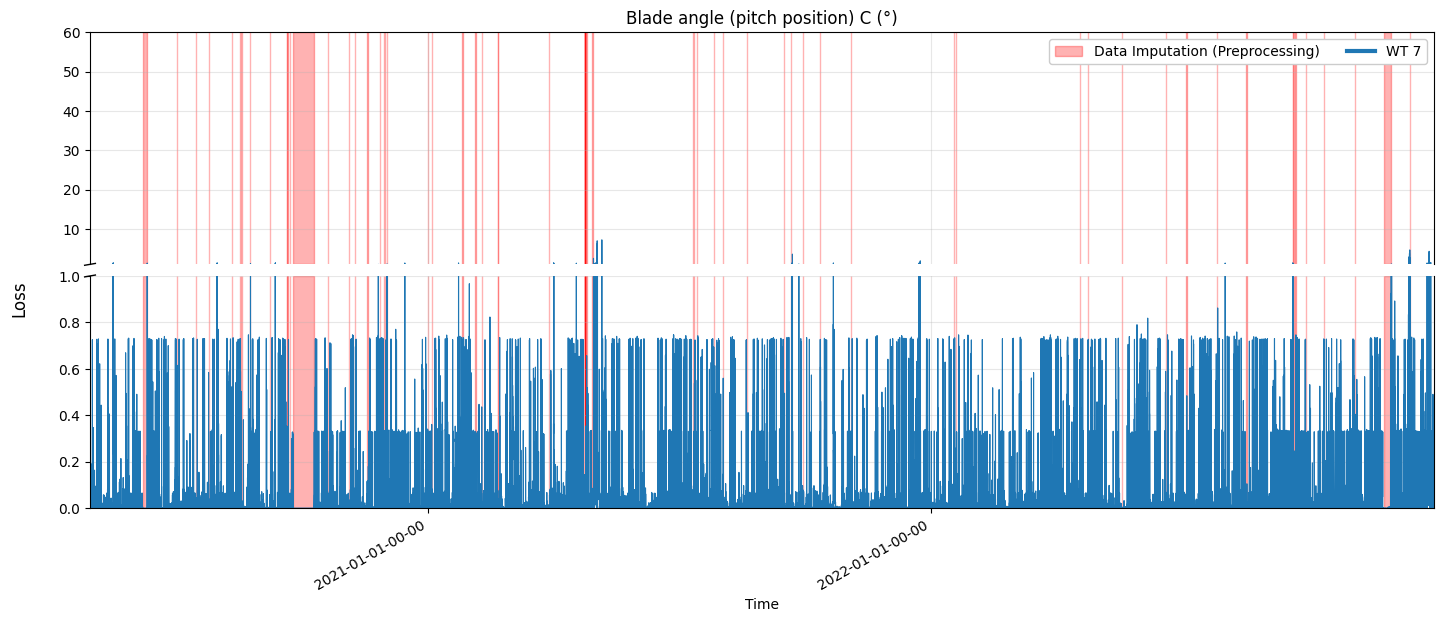

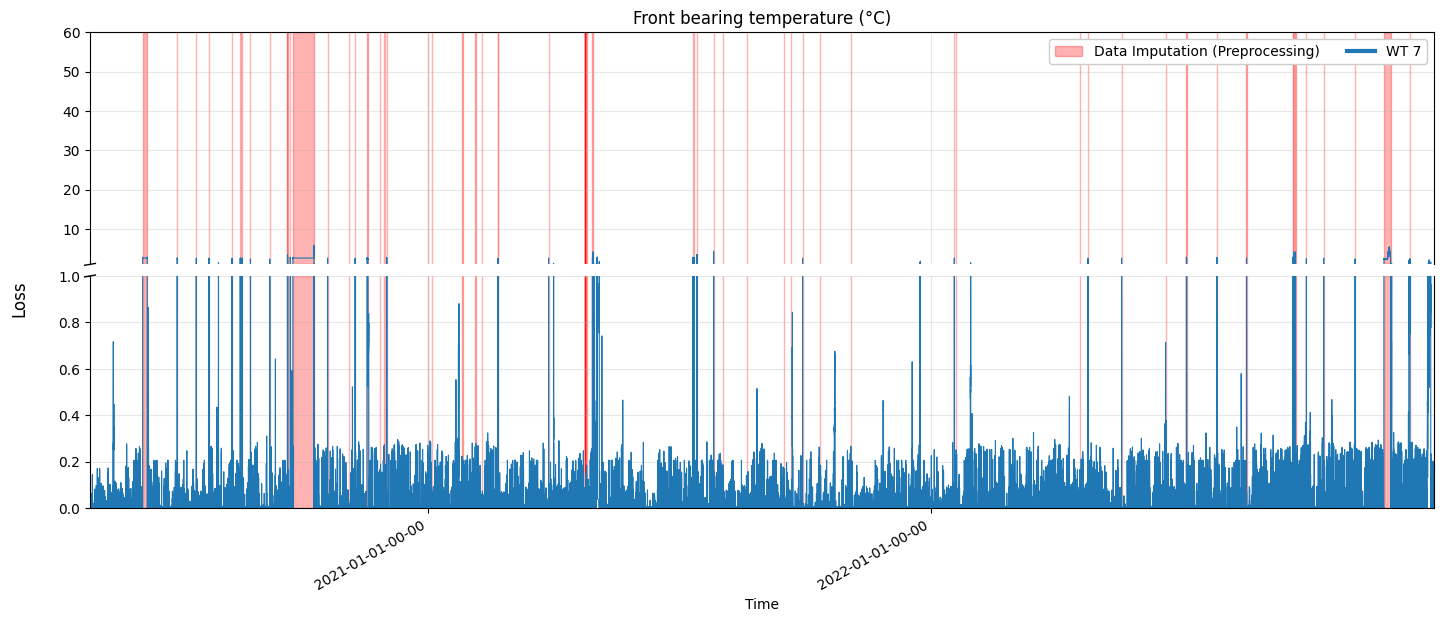

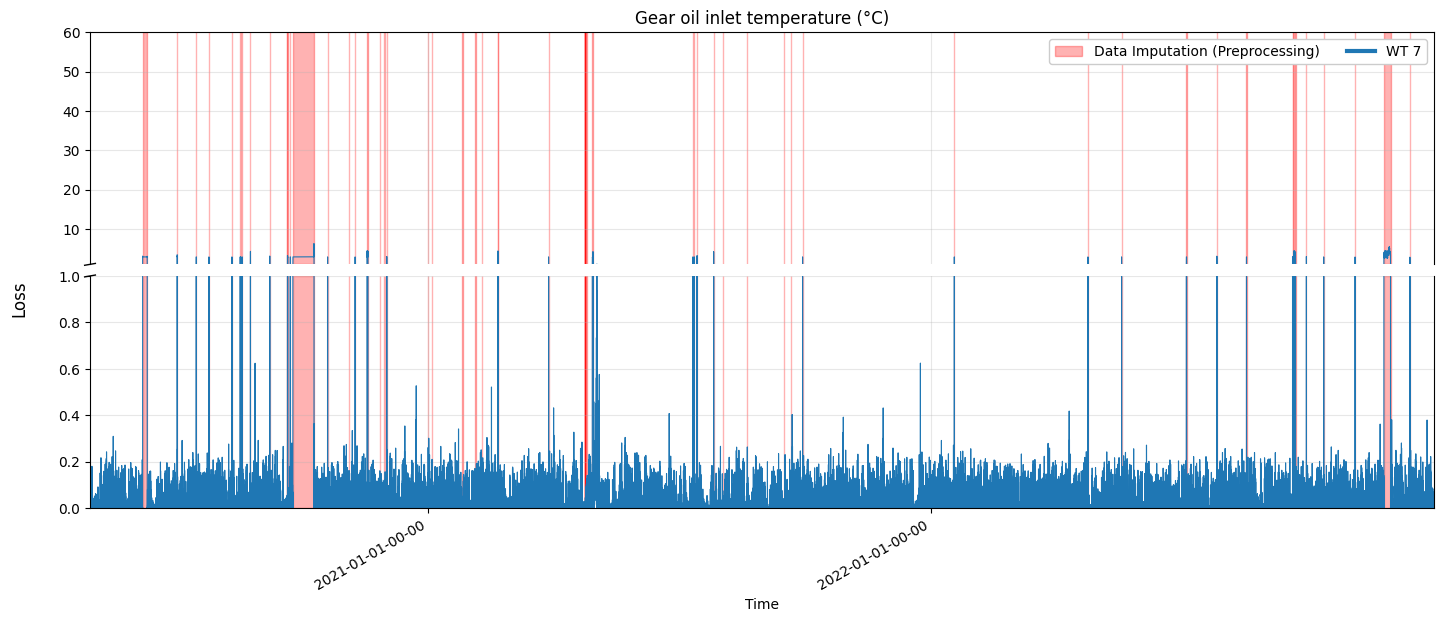

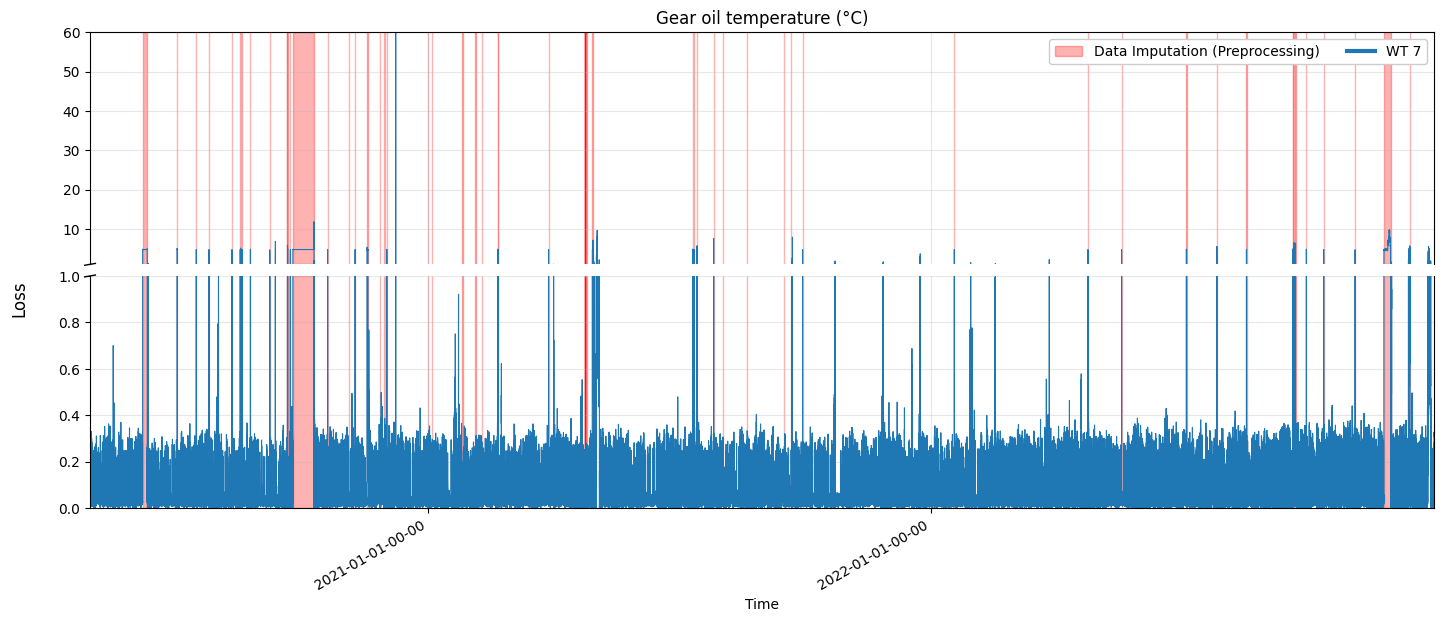

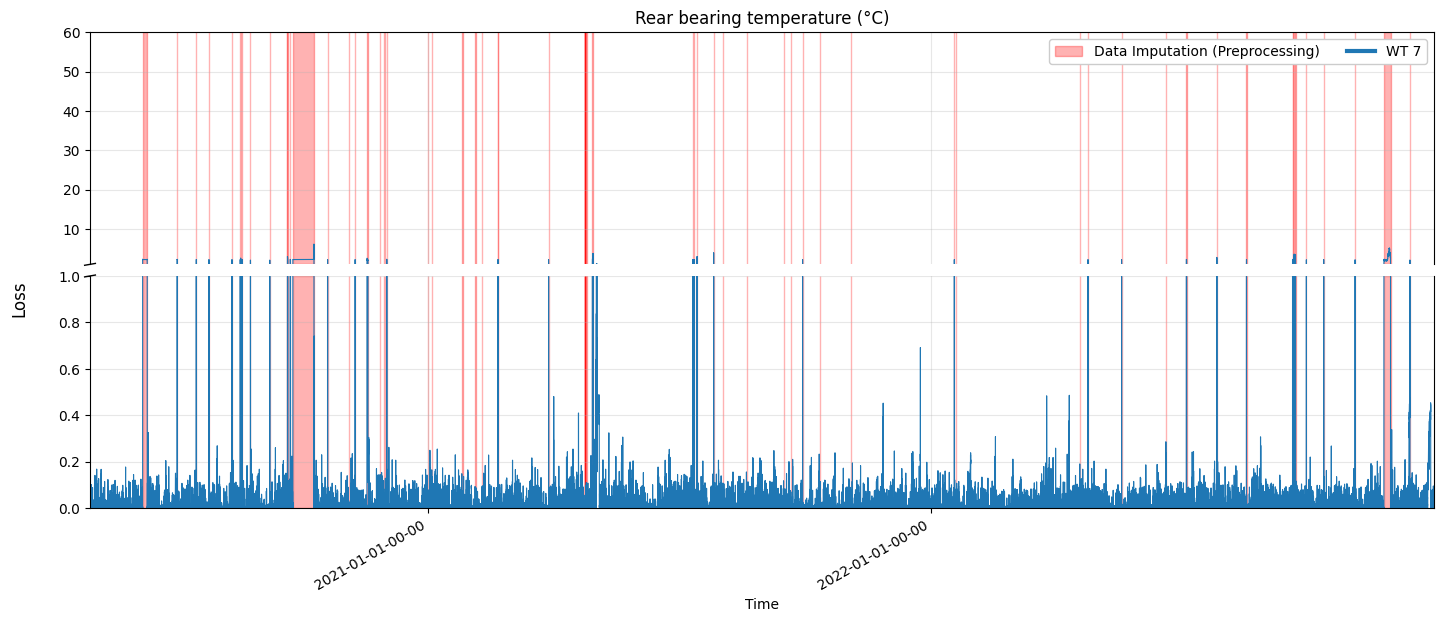

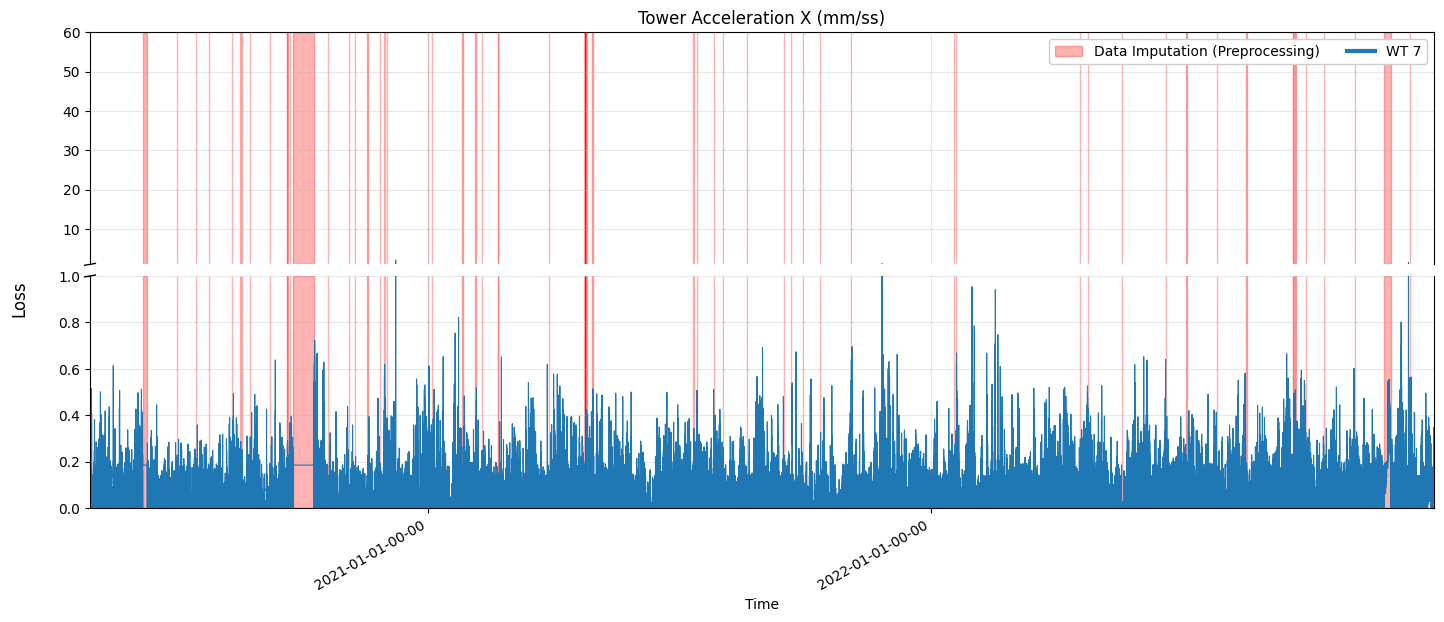

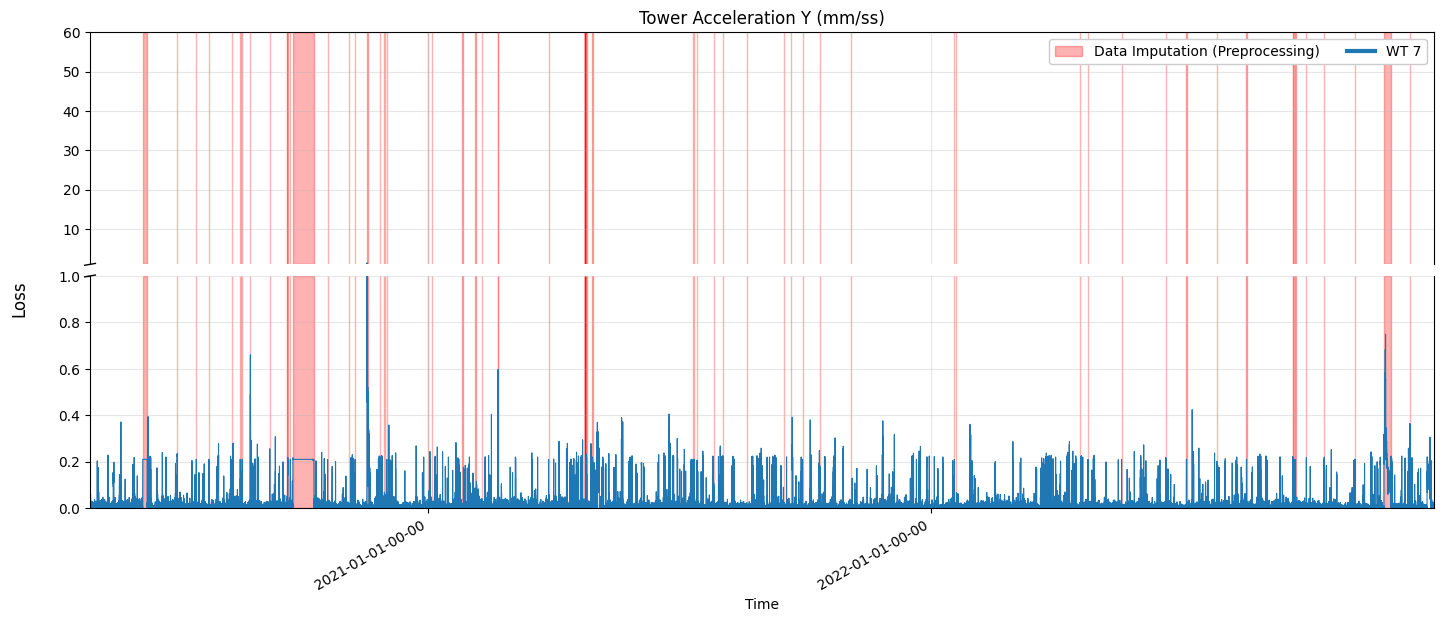

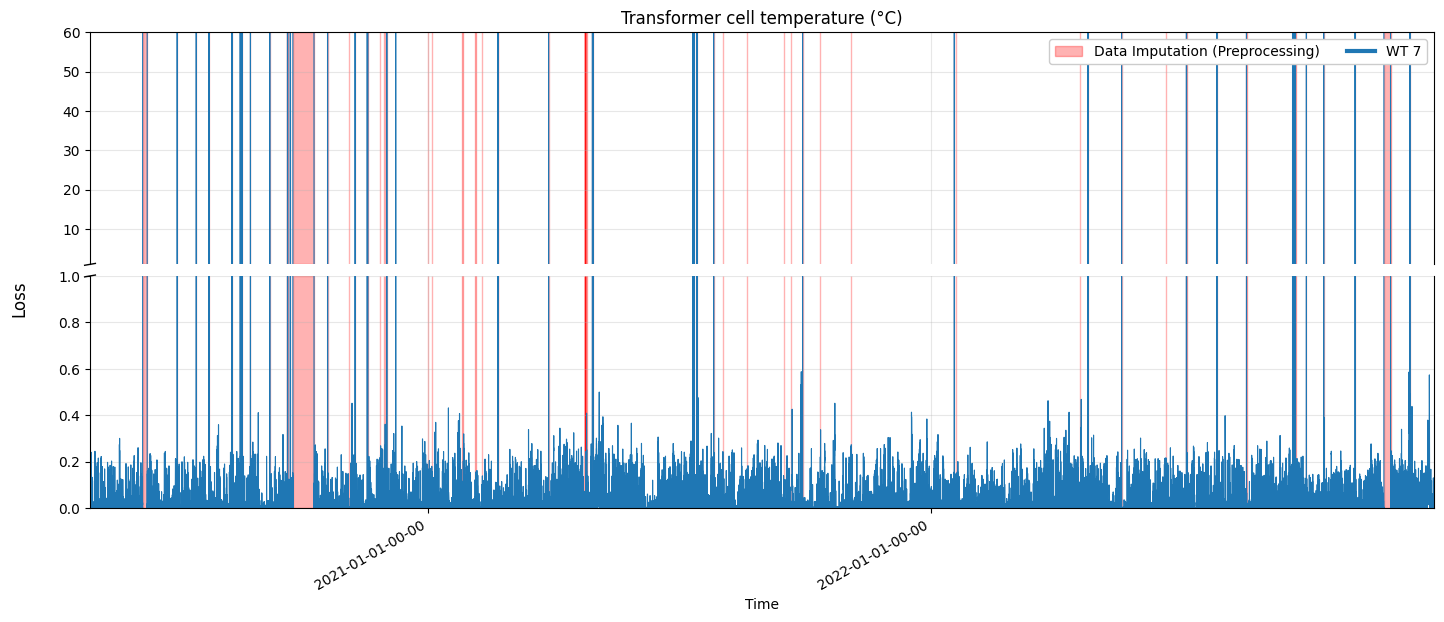

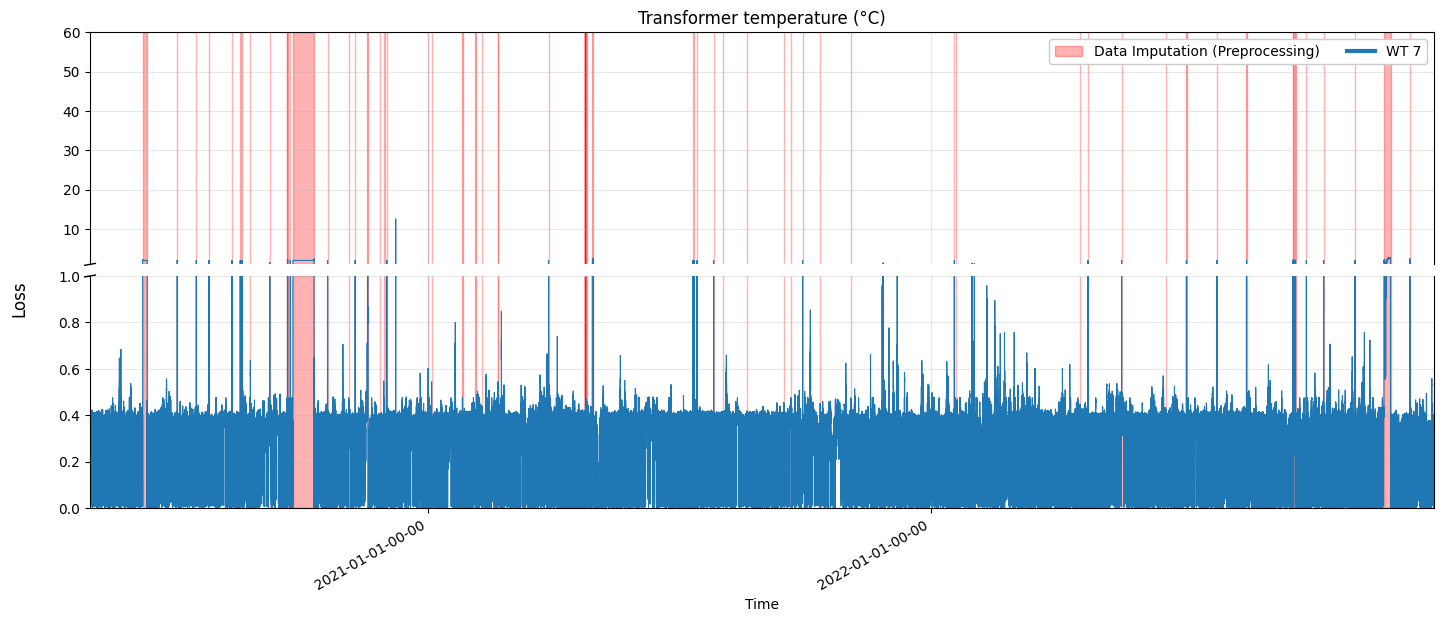

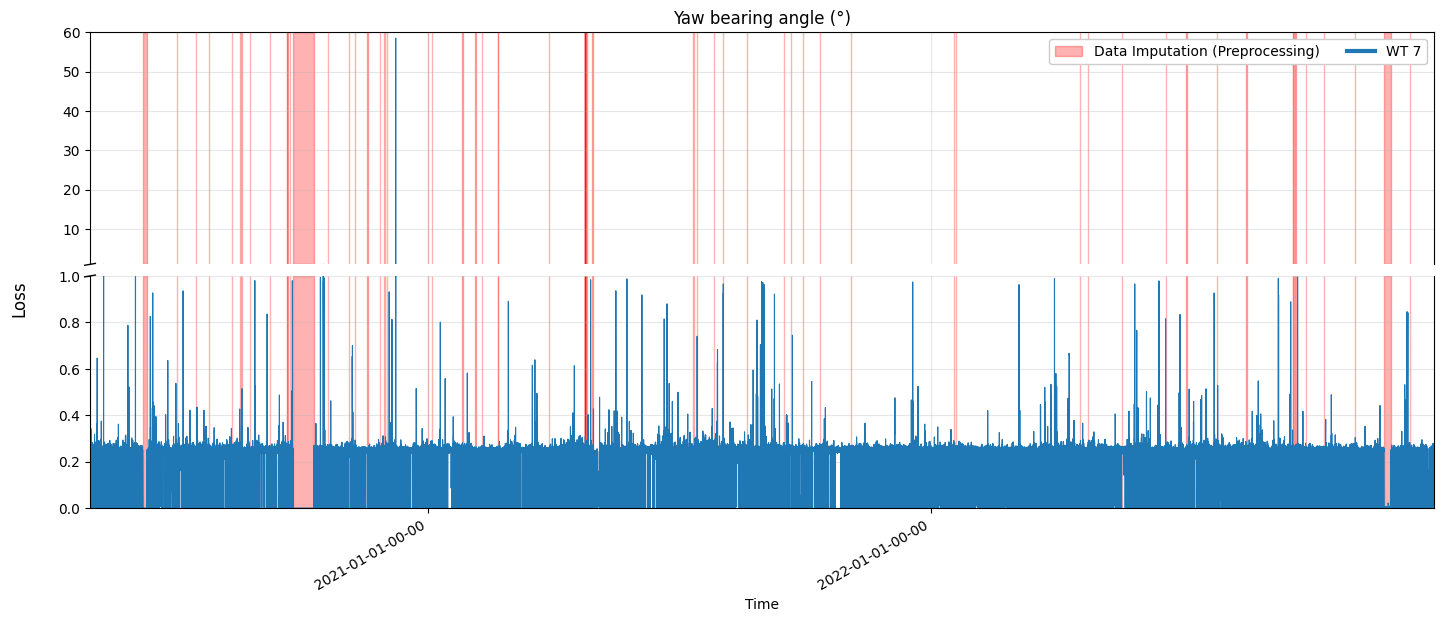

In [22]:
sigs = hfn.load_feature_order()
for sig in sigs:
    pp.print_loss(
                df_test_eval, 
                dpi=300, 
                y_limits=((0,1),(1,60)), 
                wt_id=[7],
                title=sig,
                values=f"{ic.RE_PREFIX}"+sig
                )

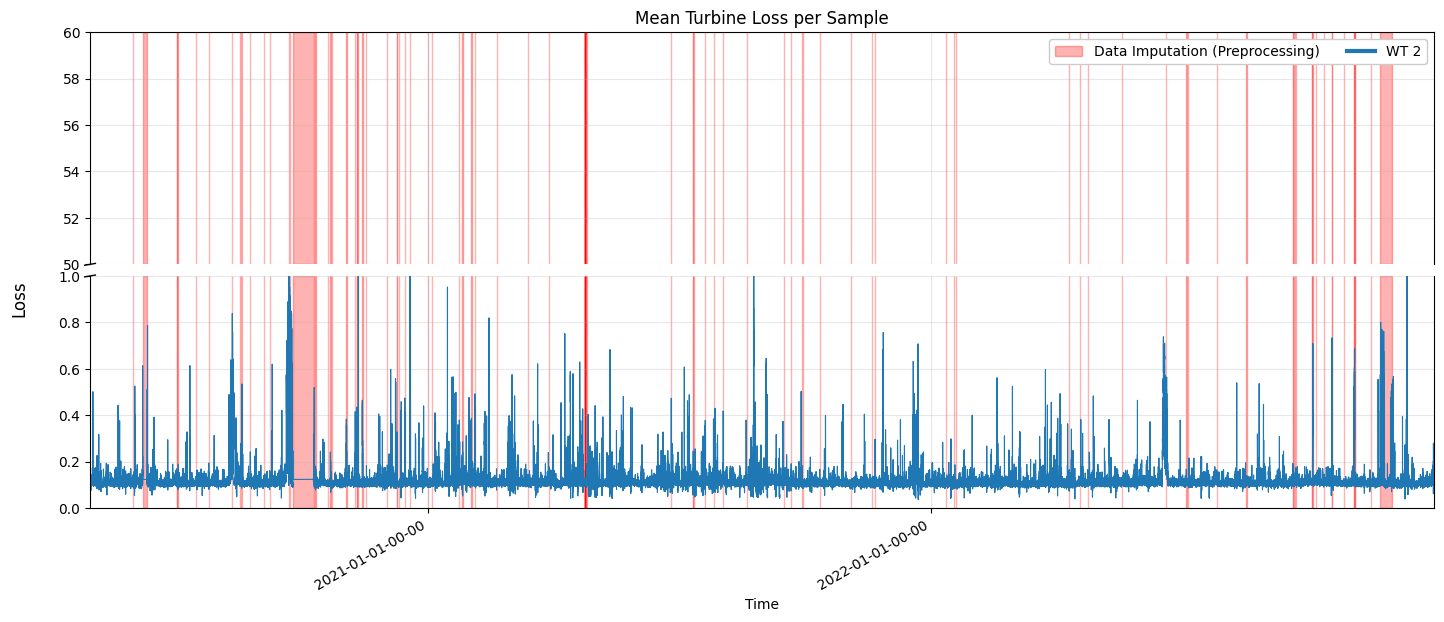

In [23]:
pp.print_loss(
            df_test_eval, 
            dpi=1024, 
            y_limits=((0,1),(50,60)), 
            wt_id=[2]
            )

In [24]:
df_test_eval.head()

,Unnamed: 0,uid,Date and time,WT_ID,Mean Loss per Sample,RE_Ambient temperature (converter) (°C),RE_Drive train acceleration (mm/ss),RE_Gear oil inlet pressure (bar),RE_Gear oil pump pressure (bar),RE_Gearbox speed (RPM),...,RE_Blade angle (pitch position) C (°),RE_Front bearing temperature (°C),RE_Gear oil inlet temperature (°C),RE_Gear oil temperature (°C),RE_Rear bearing temperature (°C),RE_Tower Acceleration X (mm/ss),RE_Tower Acceleration Y (mm/ss),RE_Transformer cell temperature (°C),RE_Transformer temperature (°C),RE_Yaw bearing angle (°)
0,842250,1588306200000000001,2020-05-01 04:10:00,1,0.057639,0.320825,0.085687,0.014958,0.034903,0.003483,...,0.001303,0.003367,0.000003,0.000577,0.000681,0.001172,0.011051,0.001361,0.362443,0.000159
1,982625,1588306200000000002,2020-05-01 04:10:00,2,0.105913,0.011373,0.059116,0.000015,0.146955,0.127164,...,0.008248,0.007354,0.215520,0.019408,0.147343,0.007921,0.078456,0.122934,0.000537,0.250895
2,1123000,1588306200000000004,2020-05-01 04:10:00,4,0.044011,0.222350,0.001554,0.017778,0.005158,0.000229,...,0.000428,0.001206,0.000106,0.001571,0.000493,0.001049,0.004008,0.002436,0.391944,0.260900
3,1263375,1588306200000000005,2020-05-01 04:10:00,5,0.067761,0.062924,0.007360,0.084649,0.020430,0.005143,...,0.005315,0.001432,0.007007,0.492303,0.001760,0.293592,0.023479,0.063509,0.005041,0.000003
4,1403750,1588306200000000006,2020-05-01 04:10:00,6,0.067226,0.005650,0.021789,0.156964,0.000053,0.000190,...,0.001438,0.000165,0.001432,0.342307,0.002534,0.189003,0.000283,0.001764,0.000036,0.000156


In [25]:
print(df_test_eval["Date and time"].min())
print(df_test_eval["Date and time"].max())

2020-05-01 04:10:00
2022-12-31 23:50:00


### free memory

In [26]:
#df_test_eval = None

### DEPRICATED: Use the quantile method to filter one more time the training data (after powercurve filtering).

In [27]:
# mean_t, elem_losses, uid_batches_t = tl.validate_epoch(model, 
#                                                         train_loader, 
#                                                         cfg.device, 
#                                                         nn.MSELoss(reduction="none"), 
#                                                         return_uids=True)

# df_re_t = tl.uids_to_wt_ts(uid_batches=uid_batches_t,
#                            elem_losses=elem_losses,
#                            loader=train_loader)

In [28]:
# os.makedirs(PATH_QUANTILE_FILTERING, exist_ok=True)

# files = glob(os.path.join(PATH_PC_FILTERING, "*.csv"))

# dfs =[pd.read_csv(fp, parse_dates=[TS_COL]) for fp in files]

# wt_ids= [df[WT_ID].iat[0] for df in dfs]

# dfs_filtered = [tl.clean_train_by_quantile(df,df_re_t,q=0.995) for df in dfs]
# [df.to_csv(os.path.join(PATH_QUANTILE_FILTERING, f"WT_ID_{wt}_train_final.csv"), index=False) for wt,df in zip(wt_ids, dfs_filtered)]



In [29]:
# print(f"available rows in train set after powercurve filtering\n{sum([len(df) for df in dfs])}")
# print(f" available rows after quantile filtering for training\n{sum([len(df) for df in dfs_filtered])}")

# free memory
# dfs_filtered = None